# Kaggle: Ефим_Плотников_1131261392

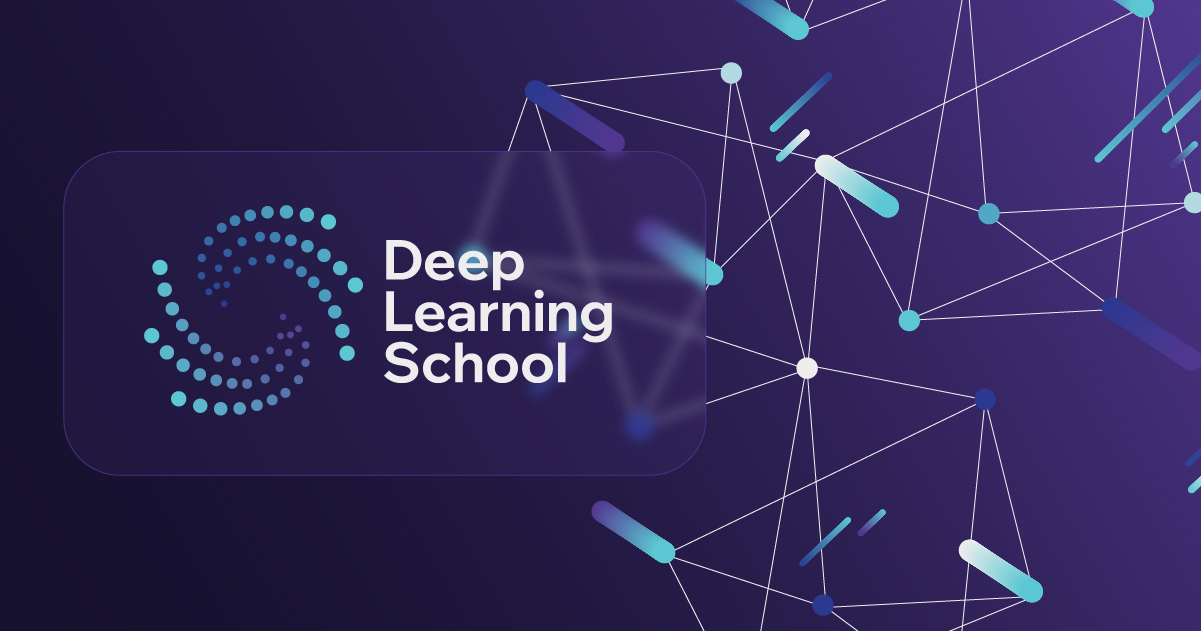


<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h3 style="text-align: center;"><b>Домашнее задание. Классификация изображений</b></h3>


# Домашнее задание. Классификация изображений

Сегодня вам предстоить помочь телекомпании FOX в обработке их контента. Как вы знаете, сериал "Симпсоны" идет на телеэкранах более 25 лет, и за это время скопилось очень много видеоматериала. Персоонажи менялись вместе с изменяющимися графическими технологиями, и Гомер Симпсон-2018 не очень похож на Гомера Симпсона-1989. В этом задании вам необходимо классифицировать персонажей, проживающих в Спрингфилде. Думаю, нет смысла представлять каждого из них в отдельности.



В нашем тесте будет 990 картнок, для которых вам будет необходимо предсказать класс.

### Установка зависимостей

In [1]:
# we will verify that GPU is enabled for this notebook
# following should print: CUDA is available!  Training on GPU ...
#
# if it prints otherwise, then you need to enable GPU:
# from Menu > Runtime > Change Runtime Type > Hardware Accelerator > GPU

import torch
import numpy as np

train_on_gpu = torch.cuda.is_available()

if not train_on_gpu:
    print('CUDA is not available.  Training on CPU ...')
else:
    print('CUDA is available!  Training on GPU ...')

CUDA is available!  Training on GPU ...


In [ ]:
# from google.colab import drive
# drive.mount('/content/gdrive/')

In [ ]:
# !unzip -q /content/gdrive/MyDrive/journey-springfield.zip

In [ ]:
# !ls train

In [ ]:
# !ls data

In [ ]:
# !ls data/train

In [4]:
import torch
torch.cuda.is_available()

True

In [6]:
import pickle
import numpy as np
from skimage import io

from tqdm import tqdm, tqdm_notebook
from PIL import Image
from pathlib import Path

from torchvision import transforms
from multiprocessing.pool import ThreadPool
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

import torch
import torchvision.io as io
import torchvision.transforms.functional as F

import pandas as pd

from matplotlib import colors, pyplot as plt
%matplotlib inline

# в sklearn не все гладко, чтобы в colab удобно выводить картинки
# мы будем игнорировать warnings
import warnings
warnings.filterwarnings(action='ignore', category=DeprecationWarning)


In [7]:
# это пакет для проверки версий других пакетов
import pkg_resources

In [8]:
!python --version

Python 3.11.9


In [10]:
for b in ['torch', 'torchvision', 'tqdm', 'matplotlib', 'seaborn', 'Pillow']:
    print(b + ' version: '+ pkg_resources.get_distribution(b).version)

torch version: 2.5.1+cu121
torchvision version: 0.20.1+cu121
tqdm version: 4.67.1
matplotlib version: 3.10.7
seaborn version: 0.13.2
Pillow version: 11.3.0


#### Версии питона и библиотек, на которых работал эталонный ноутбук:

Python 3.11.11

torch version: 2.5.1+cu124

torchvision version: 0.20.1+cu124

tqdm version: 4.67.1

matplotlib version: 3.10.0

seaborn version: 0.13.2

Pillow version: 11.1.0


In [11]:
# разные режимы датасета
DATA_MODES = ['train', 'val', 'test']
# все изображения будут масштабированы к размеру 224x224 px
RESCALE_SIZE = 224
# работаем на видеокарте
DEVICE = torch.device("cuda")

NUM_WORKERS=0

Полезная статья, которой мы вдохновились при создании класса `SimpsonsDataset`:

https://jhui.github.io/2018/02/09/PyTorch-Data-loading-preprocess_torchvision/

Ниже мы исспользуем враппер над датасетом для удобной работы. Вам стоит понимать, что происходит с LabelEncoder и  с torch.Transformation.

`ToTensor` конвертирует  `PIL Image` с параметрами в диапазоне $[0, 255]$ (как все пиксели) в `FloatTensor` размера ($C \times H \times W$) $[0,1]$ , затем производится масштабирование:
$\text{input} = \frac{\text{input} - \mu}{\text{standard deviation}} $, <br>       константы - средние и дисперсии по каналам на основе ImageNet


Стоит также отметить, что мы переопределяем метод __getitem__ для удобства работы с данной структурой данных.
 Также используется LabelEncoder для преобразования строковых меток классов в id и обратно. В описании датасета указано, что картинки разного размера, так как брались напрямую с видео, поэтому следуем привести их к одному размеру (это делает метод  _prepare_sample).

In [12]:
class SimpsonsDataset(Dataset):
    """
    Датасет с картинками, который паралельно подгружает их из папок
    производит скалирование и превращение в торчевые тензоры
    """
    def __init__(self, files, mode):
        super().__init__()
        # список файлов для загрузки
        self.files = sorted(files)
        # режим работы
        self.mode = mode

        if self.mode not in DATA_MODES:
            print(f"{self.mode} is not correct; correct modes: {DATA_MODES}")
            raise NameError

        self.len_ = len(self.files)

        self.label_encoder = LabelEncoder()

        if self.mode != 'test':
            self.labels = [path.parent.name for path in self.files]
            self.label_encoder.fit(self.labels)

            with open('label_encoder.pkl', 'wb') as le_dump_file:
                  pickle.dump(self.label_encoder, le_dump_file)

    def __len__(self):
        return self.len_

    def load_sample(self, file):
        image = Image.open(file)
        image.load()
        return image

    def __getitem__(self, index):
        # для преобразования изображений в тензоры PyTorch и нормализации входа
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])
        x = self.load_sample(self.files[index])
        x = self._prepare_sample(x)
        x = np.array(x / 255, dtype='float32')
        x = transform(x)
        if self.mode == 'test':
            return x
        else:
            label = self.labels[index]
            label_id = self.label_encoder.transform([label])
            y = label_id.item()
            return x, y

    def _prepare_sample(self, image):
        image = image.resize((RESCALE_SIZE, RESCALE_SIZE))
        return np.array(image)

In [13]:
def imshow(inp, title=None, plt_ax=plt, default=False):
    """Imshow для тензоров"""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt_ax.imshow(inp)
    if title is not None:
        plt_ax.set_title(title)
    plt_ax.grid(False)

In [94]:
#определим директории с тренировочными и тестовыми файлами
TRAIN_DIR = Path('./data/train/')
TEST_DIR = Path('./data/testset/')

In [95]:
train_val_files = sorted(list(TRAIN_DIR.rglob('*.jpg')))
test_files = sorted(list(TEST_DIR.rglob('*.jpg')))
assert len(train_val_files) > 0
assert len(test_files) > 0

In [96]:
from sklearn.model_selection import train_test_split

train_val_labels = [path.parent.name for path in train_val_files]
train_files, val_files = train_test_split(train_val_files, test_size=0.25, \
                                          stratify=train_val_labels)

In [97]:
val_dataset = SimpsonsDataset(val_files, mode='val')

In [ ]:
# uncomment if you have problem with pillow
# def register_extension(id, extension): Image.EXTENSION[extension.lower()] = id.upper()
# Image.register_extension = register_extension
# def register_extensions(id, extensions):
#     for extension in extensions: register_extension(id, extension)
# Image.register_extensions = register_extensions

**!** Обратите внимание, что возможно, датасет требует дополнительной фильтрации, так как лейблы не всегда точно соответствуют картинкам.

Давайте посмотрим на наших героев внутри датасета.

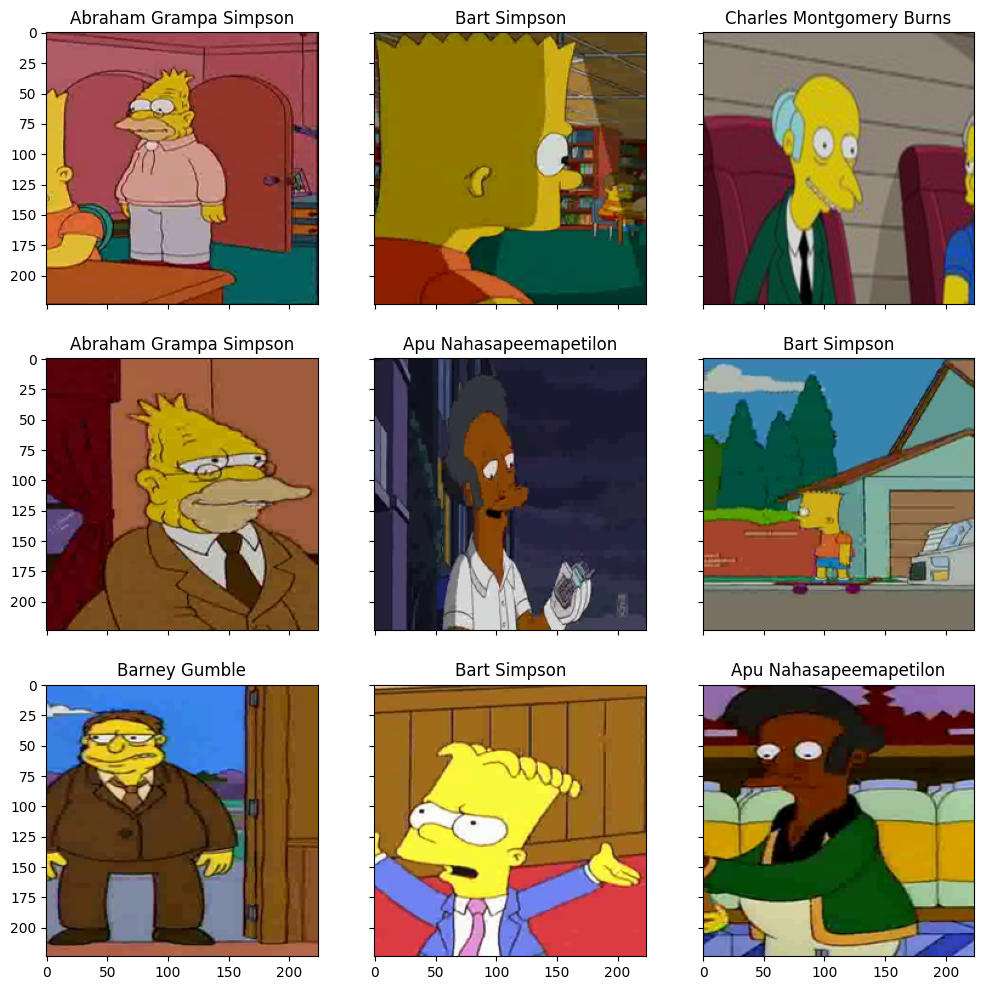

In [21]:
fig, ax = plt.subplots(nrows=3, ncols=3,figsize=(12, 12), \
                        sharey=True, sharex=True)
for fig_x in ax.flatten():
    random_characters = int(np.random.uniform(0,1000))
    im_val, label = val_dataset[random_characters]
    img_label = " ".join(map(lambda x: x.capitalize(),\
                val_dataset.label_encoder.inverse_transform([label])[0].split('_')))
    imshow(im_val.data.cpu(), \
          title=img_label,plt_ax=fig_x)

Можете добавить ваши любимые сцены и классифицировать их. (веселые результаты можно кидать в чат)

### Построение нейросети

Запустить данную сеть будет вашим мини-заданием на первую неделю, чтобы было проще участвовать в соревновании.

Данная архитектура будет очень простой и нужна для того, чтобы установить базовое понимание и получить простенький сабмит на Kaggle.

<!-- Здесь вам предлагается дописать сверточную сеть глубины 4/5.  -->

*Описание слоев*:



1. размерность входа: $3\times 224 \times 224$
2.размерности после слоя:  $8 \times 111 \times 111$
3. $16 \times 54 \times 54$
4. $32 \times 26 \times 26$
5. $64 \times 12 \times 12$
6. выход: $96 \times 5 \times 5$

О том, как работают свёртки подробней можно прочитать в документации Pytorch на функцию `Conv2d`:

https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html

Калькулятор свёрток:

https://madebyollin.github.io/convnet-calculator/

#### Модель

In [23]:
class SimpleCnn(nn.Module):
    """
    Очень простая сверточная нейронная сеть для классификации изображений.

    Эта сеть состоит из пяти сверточных слоев, каждый из которых
    включает в себя операцию свертки, функцию активации ReLU и операцию
    пулинга (max-pooling). На выходе используется полносвязный слой
    для классификации на заданное количество классов.

    Параметры:
    ----------
    n_classes : int
        Количество классов для классификации.

    Примечание:
    ----------
    Входные изображения должны иметь размерность (3, H, W), где
    3 - слои rgb для цветной картинки, а H и W - высота и ширина изображения,
    соответственно. Размер выходного тензора будет равен (n_classes).

    Методы:
    -------
    forward(x):
        Пропускает входные данные через сеть и возвращает логиты для
        каждого класса.
    """

    def __init__(self, n_classes):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=8, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv4 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv5 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=96, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.out = nn.Linear(96 * 5 * 5, n_classes)


    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.conv5(x)

        x = x.view(x.size(0), -1)
        logits = self.out(x)
        return logits

#### Функция обучения:

In [24]:
def fit_epoch(model, train_loader, criterion, optimizer):
    """
    Функция обучает модель на одной эпохе, используя предоставленный dataloader.

    Эта функция проходит по всем данным в `train_loader`, выполняет шаг моделью (forward),
    вычисляет лосс, выполняет обратное распространение с помощью заданного
    оптимизатора и обновляет веса модели.
    В конце эпохи возвращаются средний лосс и
    точность на обучающем наборе данных.

    Параметры:
    ----------
    model : nn.Module
        Модель, которую необходимо обучить. Должна быть экземпляром класса
        PyTorch `nn.Module`.

    train_loader : DataLoader
        Загрузчик данных, который предоставляет батчи входных данных и
        соответствующих меток. Должен возвращать кортежи (inputs, labels).

    criterion : nn.Module
        Функция потерь, используемая для вычисления ошибки между
        предсказаниями модели и истинными метками.

    optimizer : torch.optim.Optimizer
        Оптимизатор, используемый для обновления весов модели на основе
        градиентов, вычисленных в процессе обучения.

    Функция возвращает:
    ----------
    tuple
        Кортеж, содержащий средний лосс (train_loss) и точность (train_acc)
        на обучающем наборе данных за текущую эпоху.
    """

    running_loss = 0.0
    running_corrects = 0
    processed_data = 0

    for inputs, labels in train_loader:
        inputs = inputs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        preds = torch.argmax(outputs, 1)
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
        processed_data += inputs.size(0)

    train_loss = running_loss / processed_data
    train_acc = running_corrects.cpu().numpy() / processed_data
    return train_loss, train_acc

#### Функция валидации:

In [25]:
def eval_epoch(model, val_loader, criterion):
    """
    Функция оценивает работу модели на валидационном наборе данных за одну эпоху.

    Эта функция проходит по всем данным в `val_loader`, выполняет прямое
    распространение, вычисляет лосс и точность модели. В конце эпохи
    возвращаются средний лосс и точность на валидационном наборе данных.

    Параметры:
    ----------
    model : nn.Module
        Модель, которую необходимо оценить. Должна быть экземпляром класса
        PyTorch `nn.Module`.

    val_loader : DataLoader
        Загрузчик данных, который предоставляет батчи входных данных и
        соответствующих меток для валидации. Должен возвращать кортежи
        (inputs, labels).

    criterion : nn.Module
        Функция потерь, используемая для вычисления ошибки между
        предсказаниями модели и истинными метками.

    Функция возвращает:
    ----------
    tuple
        Кортеж, содержащий среднюю потерю (val_loss) и точность (val_acc)
        на валидационном наборе данных за текущую эпоху.
    """
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    processed_size = 0

    for inputs, labels in val_loader:
        inputs = inputs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        with torch.set_grad_enabled(False):
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            preds = torch.argmax(outputs, 1)

        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
        processed_size += inputs.size(0)
    val_loss = running_loss / processed_size
    val_acc = running_corrects.double() / processed_size
    return val_loss, val_acc

#### Полный цикл обучения

In [100]:
def train(train_dataset, val_dataset, model, epochs, batch_size, optimizer=None, cb_checkpoint=None):
    """
    Функция обучает модель на обучающем наборе данных и оценивает ее на валидационном наборе данных.

    Эта функция создает загрузчики данных для обучающего и валидационного наборов,
    а затем выполняет обучение модели в течение заданного количества эпох.
    В конце каждой эпохи выводятся значения потерь и точности для обучающего и
    валидационного наборов. История обучения сохраняется и возвращается.

    Параметры:
    ----------
    train_dataset
        Обучающие данные.

    val_dataset
        Валидационные данные.

    model : nn.Module
        Модель, которую необходимо обучить. Должна быть экземпляром класса
        PyTorch `nn.Module`.

    epochs : int
        Количество эпох для обучения модели.

    batch_size : int
        Размер батча, используемый для загрузки данных.

    Возвращает:
    ----------
    list
        Список, содержащий кортежи (train_loss, train_acc, val_loss, val_acc)
        для каждой эпохи, где:
        - train_loss: средняя потеря на обучающем наборе.
        - train_acc: точность на обучающем наборе.
        - val_loss: средняя потеря на валидационном наборе.
        - val_acc: точность на валидационном наборе.
    """
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=NUM_WORKERS)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS)

    history = []
    log_template = "\nEpoch {ep:03d} train_loss: {t_loss:0.4f} \
    val_loss {v_loss:0.4f} train_acc {t_acc:0.4f} val_acc {v_acc:0.4f}"

    with tqdm(desc="epoch", total=epochs) as pbar_outer:
        if optimizer is None:
            optimizer = torch.optim.Adam(model.parameters())
        else:
            # К готовому коду из исходного ноутбука
            # добавляем возможность подменить оптимизатор
            pass 
        
        criterion = nn.CrossEntropyLoss()

        best_val_loss = 999999.9
        for epoch in range(epochs):
            train_loss, train_acc = fit_epoch(model, train_loader, criterion, optimizer)
            print("loss", train_loss)

            val_loss, val_acc = eval_epoch(model, val_loader, criterion)
            history.append((train_loss, train_acc, val_loss, val_acc))

            pbar_outer.update(1)
            tqdm.write(log_template.format(ep=epoch+1, t_loss=train_loss,\
                                           v_loss=val_loss, t_acc=train_acc, v_acc=val_acc))
            
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                torch.save({
                    'epoch': epoch,
                    'model_state': model.state_dict(),
                    'optim_state': optimizer.state_dict(),
                    'val_loss': val_loss, 
                    'val_acc': val_acc, 
                }, f"best_model.pth")

            if (epoch + 1) % 32 == 0:
                if cb_checkpoint is not None:
                    cb_checkpoint(history)
                
                torch.save({
                    'epoch': epoch,
                    'model_state': model.state_dict(),
                    'optim_state': optimizer.state_dict(),
                    'val_acc': val_acc, 
                }, f"checkpoint_{epoch}.pth")

    return history

#### Применение модели к данным

In [29]:
def predict(model, test_loader):
    """
    Функция выполняет предсказание классов для тестового набора данных с использованием обученной модели.

    Эта функция принимает модель и загрузчик тестовых данных, применяет модель к
    изображениям и возвращает вероятности предсказанных классов.

    Параметры:
    ----------
    model : nn.Module
        Обученная модель, которая будет использоваться для предсказания.
        Должна быть экземпляром класса PyTorch `nn.Module`.

    test_loader : DataLoader
        Загрузчик данных, который предоставляет батчи входных данных для тестирования.
        Должен возвращать тензоры входных данных.

    Возвращает:
    ----------
    numpy.ndarray
        Массив вероятностей предсказанных классов для каждого примера в тестовом наборе.
        Размерность массива будет (N, C), где N - количество примеров, а C - количество классов.
    """

    with torch.no_grad():
        logits = []

        for inputs in test_loader:
            inputs = inputs.to(DEVICE)
            model.eval()
            outputs = model(inputs).cpu()
            logits.append(outputs)

    probs = nn.functional.softmax(torch.cat(logits), dim=-1).numpy()
    return probs

In [30]:
n_classes = len(np.unique(train_val_labels))
simple_cnn = SimpleCnn(n_classes).to(DEVICE)
print("we will classify: {} classes".format(n_classes))
print(simple_cnn)

we will classify: 42 classes
SimpleCnn(
  (conv1): Sequential(
    (0): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv3): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv4): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv5): Sequential(
    (0): Conv2d(64, 96, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (out): Linear(in_features=2400,

Запустим обучение сети.

In [85]:
if val_dataset is None:
    val_dataset = SimpsonsDataset(val_files, mode='val')

train_dataset = SimpsonsDataset(train_files, mode='train')

In [32]:
optimizer = torch.optim.Adam(simple_cnn.parameters())
# history = train(train_dataset, val_dataset, model=simple_cnn, epochs=2, batch_size=64)

Построим кривые обучения

In [ ]:
loss, acc, val_loss, val_acc = zip(*history)

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(loss, label="train_loss")
plt.plot(val_loss, label="val_loss")
plt.legend(loc='best')
plt.xlabel("epochs")
plt.ylabel("loss")
plt.show()

### Ну и что теперь со всем этим делать?

![alt text](https://www.indiewire.com/wp-content/uploads/2014/08/the-simpsons.jpg)

Хорошо бы понять, как сделать сабмит.
У нас есть сеть и методы eval у нее, которые позволяют перевести сеть в режим предсказания. Стоит понимать, что у нашей модели на последнем слое стоит `softmax`, которые позволяет получить вектор вероятностей  того, что объект относится к тому или иному классу. Давайте воспользуемся этим.

In [33]:
def predict_one_sample(model, inputs, device=DEVICE):
    """Предсказание, для одной картинки"""
    with torch.no_grad():
        inputs = inputs.to(device)
        model.eval()
        logit = model(inputs).cpu()
        probs = torch.nn.functional.softmax(logit, dim=-1).numpy()
    return probs

In [34]:
random_characters = int(np.random.uniform(0,1000))
ex_img, true_label = val_dataset[random_characters]
probs_im = predict_one_sample(simple_cnn, ex_img.unsqueeze(0))

In [35]:
idxs = list(map(int, np.random.uniform(0,1000, 20)))
imgs = [val_dataset[id][0].unsqueeze(0) for id in idxs]

probs_ims = predict(simple_cnn, imgs)

In [36]:
label_encoder = pickle.load(open("label_encoder.pkl", 'rb'))

In [37]:
y_pred = np.argmax(probs_ims,-1)

actual_labels = [val_dataset[id][1] for id in idxs]

preds_class = [label_encoder.classes_[i] for i in y_pred]

Обратите внимание, что метрика, которую необходимо оптимизировать в конкурсе -- `f1-score`.

Вычислим целевую метрику на валидационной выборке.

In [38]:
from sklearn.metrics import f1_score
f1 = f1_score(actual_labels, y_pred, average='micro')

print("F1-оценка:", f1)

F1-оценка: 0.0


Сделаем классную визуализацию,  чтобы посмотреть насколько сеть уверена в своих ответах. Можете исспользовать это, чтобы отлаживать правильность вывода.

In [ ]:
import matplotlib.patches as patches
from matplotlib.font_manager import FontProperties

fig, ax = plt.subplots(nrows=3, ncols=3,figsize=(12, 12), \
                        sharey=True, sharex=True)
for fig_x in ax.flatten():
    random_characters = int(np.random.uniform(0,1000))
    im_val, label = val_dataset[random_characters]
    img_label = " ".join(map(lambda x: x.capitalize(),\
                val_dataset.label_encoder.inverse_transform([label])[0].split('_')))



    imshow(im_val.data.cpu(), \
          title=img_label,plt_ax=fig_x)

    actual_text = "Actual : {}".format(img_label)

    fig_x.add_patch(patches.Rectangle((0, 0),220,17,color='white'))
    font0 = FontProperties()
    font = font0.copy()
    font.set_family("serif")
    prob_pred = predict_one_sample(simple_cnn, im_val.unsqueeze(0))
    predicted_proba = np.max(prob_pred)*100
    y_pred = np.argmax(prob_pred)

    predicted_label = label_encoder.classes_[y_pred]
    predicted_text = "{} : {:.0f}%".format(predicted_label,predicted_proba)

    fig_x.text(5, 4, predicted_text , horizontalalignment='left', fontproperties=font,
                    verticalalignment='top',fontsize=10, color='black')

Попробуйте найти те классы, которые сеть не смогла расспознать. Изучите данную проблему, это понадобится в дальнейшем.

### Submit на Kaggle

![alt text](https://i.redd.it/nuaphfioz0211.jpg)

In [51]:
test_dataset = SimpsonsDataset(test_files, mode="test")
test_loader = DataLoader(test_dataset, shuffle=False, batch_size=64, num_workers=NUM_WORKERS)
probs = predict(simple_cnn, test_loader)


preds = label_encoder.inverse_transform(np.argmax(probs, axis=1))
test_filenames = [path.name for path in test_dataset.files]


## Приключение?

А теперь самое интересное, мы сделали простенькую сверточную сеть и смогли отправить сабмит, но получившийся скор нас явно не устраивает. Надо с этим что-то сделать.

Несколько срочныйх улучшейни для нашей сети, которые наверняка пришли Вам в голову:
1. Работа с датасетом:
* проверка (EDA) и предобработка;
* дополнение, выравниванике кол-ва картинок в классах - изменять можно как сами картинки, формируя новый датасет, или в класссе SimpsonsDataset;
* с помощью [аугментации](https://habr.com/ru/companies/smartengines/articles/264677/) или [без](https://www.geeksforgeeks.org/python-data-augmentation/);

2. Рабта с архитектурой сети:
* учим дольше и изменяем (подбираем) гиперпараметры: learning rate, batch size, нормализация картинки и вот это всё;
* добавление/удаление свёрточных слоёв;
* кто же так строит нейронные сети? А где пулинги и батч нормы? Надо добавлять!

3. Улучшение оптимизации:
* ну разве Адам наше все? [adamW](https://www.fast.ai/2018/07/02/adam-weight-decay/) для практика, [статейка для любителей](https://openreview.net/pdf?id=ryQu7f-RZ) (очень хороший анализ), [наши ](https://github.com/MichaelKonobeev/adashift/) эксперименты для заинтересованных.

4. Файнтютинг и трансферлёнинг:
* ну разве это deep learning? Вот ResNet и Inception, которые можно зафайнтьюнить под наши данные, вот это я понимаю (можно и обучить в колабе, а можно и [готовые](https://github.com/Cadene/pretrained-models.pytorch) скачать).

5. Стоит подумать об ансамблях


Надеюсь, что у Вас получится!

![alt text](https://pbs.twimg.com/profile_images/798904974986113024/adcQiVdV.jpg)


---
# Начало решения 

Predict + Submit удобно выделить в функцию

In [40]:
def predict_and_submit(model, submit_name):
    probs = predict(model, test_loader)
    preds = label_encoder.inverse_transform(np.argmax(probs, axis=1))
    submit = pd.DataFrame({'Id': test_filenames, 'Expected': preds})
    submit.to_csv(f'{submit_name}.csv', index=False)

Аналогично и с графиком лосса по эпохам

In [90]:
def plot_epoch_loss(history):
    loss, acc, val_loss, val_acc = zip(*history)

    plt.figure(figsize=(7, 4))
    plt.plot(loss, label="train_loss")
    plt.plot(val_loss, label="val_loss")
    plt.legend(loc='best')
    plt.xlabel("epochs")
    plt.ylabel("loss")
    plt.ylim(0, 1.5) 
    plt.show()

И для расчета F1-оценки

In [42]:
def evaluate_f1_score(model):
    idxs = list(map(int, np.random.uniform(0,1000, 800)))
    imgs = [val_dataset[id][0].unsqueeze(0) for id in idxs]
    probs_ims = predict(model, imgs)
    y_pred = np.argmax(probs_ims,-1)
    actual_labels = [val_dataset[id][1] for id in idxs]
    return f1_score(actual_labels, y_pred, average='micro')

# Борис Треухов посоветовал

> ахтунг ахтунг, вот ща в правильный поток написал )
> 
> короче, очень сильно ускоряется на локальной видюхе если через торчвижн сразу загружать в ГПУ без всяких Pillow

> import torchvision.io as io
> def load_image(self, file):
>         data = io.read_file(str(file))
>         return io.decode_jpeg(data, device='cuda')

> ну мб кому то подойдет больше CPU вариант, а потом (tensor_transformed.to('cuda', non_blocking=True)) если аугментаций много

> еще у меня последняя версия libjpeg turbo из репы собрана, не знаю влияет или нет но ускорилось 2.5x

> P.S. еще io.decode_jpeg список(list) CPU тензоров принимает(по крайней мере в последней версии торчвижн) - можно засосать весь датасет при желании(вроде 12гб) либо сделать коллацию батча попробовать чтобы хотя бы батч одним.. батчем сразу распаковывать из JPG прямо на GPU - nb сами JPEG всегда приходят как CPU тензоры, но распаковываются как GPU тензоры если device='cuda' указать


Я как раз тренирую локально на 4070 ti, время не прочь сэкономить, так что ниже - реализация даталоадера по советам выше.

In [43]:
class SimpsonsDatasetGpu(Dataset):
    def __init__(self, files, mode):
        super().__init__()
        self.files = sorted(files)
        self.mode = mode
        self.len_ = len(self.files)
        self.rescale = (RESCALE_SIZE, RESCALE_SIZE)
        self.mean = [0.485, 0.456, 0.406]
        self.std  = [0.229, 0.224, 0.225]

        if self.mode != 'test':
            self.labels = [path.parent.name for path in self.files]
            self.label_encoder = LabelEncoder()
            self.label_encoder.fit(self.labels)
        else:
            self.labels = None
            self.label_encoder = None

    def __len__(self):
        return self.len_

    def load_sample(self, file):
        data = io.read_file(str(file))                 # CPU bytes
        img = io.decode_jpeg(data, device='cuda')     # uint8 tensor на CUDA
        return img

    def __getitem__(self, index):
        x = self.load_sample(self.files[index])       # uint8 CUDA tensor
        x = x.to(dtype=torch.float32).div_(255.0)     # float32 на CUDA в [0,1]
        x = F.resize(x, self.rescale)                 # resize на CUDA
        x = F.normalize(x, mean=self.mean, std=self.std)  # нормализация на CUDA
        if self.mode == 'test':
            return x
        label = self.labels[index]
        y = int(self.label_encoder.transform([label])[0])
        return x, y


Теперь надо датасеты перевести на этот оптимизированный вариант.

In [98]:
val_dataset = SimpsonsDatasetGpu(val_files, mode='val')
train_dataset = SimpsonsDatasetGpu(train_files, mode='train')
test_dataset = SimpsonsDatasetGpu(test_files, mode="test")

test_loader = DataLoader(test_dataset, shuffle=False, batch_size=64, num_workers=NUM_WORKERS)
test_filenames = [path.name for path in test_dataset.files]


Забегая вперёд - это действительно дало ускорение и действительно в 2.5 раза


# Простые эксперименты с базовой моделью
Для начала я попробую базовую модель обучить с большим количеством эпох.
А то грустно было смотреть на графики выше, где просто 2 отрезка

epoch:   0%|          | 0/8 [00:00<?, ?it/s]

loss 2.6698685405102345


epoch:  12%|█▎        | 1/8 [00:54<06:21, 54.54s/it]


Epoch 001 train_loss: 2.6699     val_loss 2.0578 train_acc 0.2582 val_acc 0.4375
loss 1.549490098057526


epoch:  25%|██▌       | 2/8 [01:32<04:28, 44.72s/it]

...


Epoch 006 train_loss: 0.3606     val_loss 0.9906 train_acc 0.8966 val_acc 0.7807
loss 0.26902087615875614


epoch:  88%|████████▊ | 7/8 [04:42<00:38, 38.86s/it]


Epoch 007 train_loss: 0.2690     val_loss 1.0076 train_acc 0.9195 val_acc 0.7864
loss 0.1951573456090775


epoch: 100%|██████████| 8/8 [05:20<00:00, 40.10s/it]


Epoch 008 train_loss: 0.1952     val_loss 1.1869 train_acc 0.9396 val_acc 0.7818


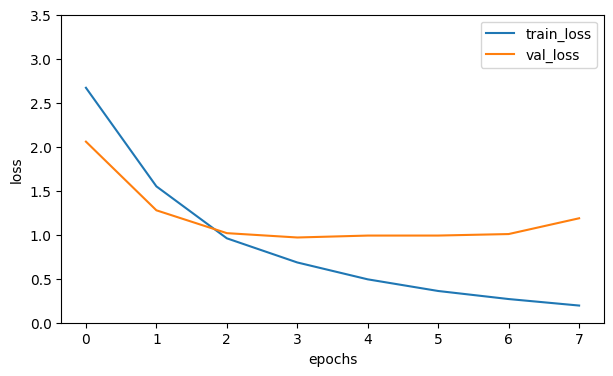

F1: 0.77625


RuntimeError: torch.cat(): expected a non-empty list of Tensors

In [45]:
simple_cnn_8 = SimpleCnn(n_classes).to(DEVICE)
history = train(train_dataset, val_dataset, model=simple_cnn_8, epochs=8, batch_size=64)
plot_epoch_loss(history)
print(f"F1: {evaluate_f1_score(simple_cnn_8)}")
predict_and_submit(model=simple_cnn_8, submit_name="simple_cnn_8_epochs")

Простым увеличением кол-ва эпох на kaggle получается 0.89, уже неплохо, не ноль баллов. Странно правда, почему так много, локально на тесте 0.74, возможно на каггле тестовая выборка маленькая и просто повезло?

При этом, судя по графику, насыщения не произошло, можно еще зарядить эпох и посмотреть, что дальше.

In [ ]:
simple_cnn_16 = SimpleCnn(n_classes).to(DEVICE)
history = train(train_dataset, val_dataset, model=simple_cnn_16, epochs=16, batch_size=64)

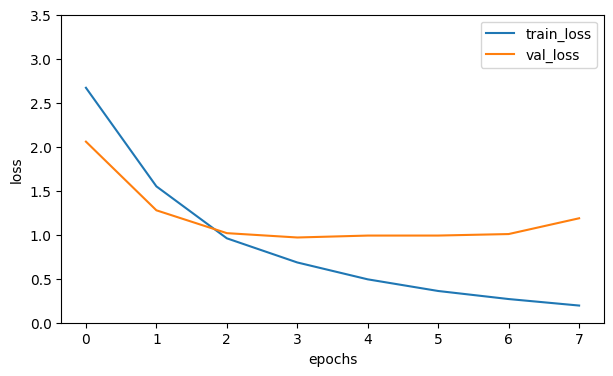

NameError: name 'simple_cnn_16' is not defined

In [46]:
plot_epoch_loss(history)
print(f"F1: {evaluate_f1_score(simple_cnn_16)}")
predict_and_submit(model=simple_cnn_16, submit_name="simple_cnn_16_epochs")

Лучше не становится, только расходиться начинает

# Fine-tuning чего-то посложнее

Умные люди уже придумали архитектуры за нас и пожгли видеокарты чтобы обучить более сложные модели. Попробуем паразитировать на этом, чтобы уложиться в дедлайны домашки.

In [52]:
!pip install timm
import timm

     ---------------------------------------- 0.0/63.1 kB ? eta -:--:--
     ------------------ ------------------- 30.7/63.1 kB 640.0 kB/s eta 0:00:01
     ---------------------------------------- 63.1/63.1 kB 1.1 MB/s eta 0:00:00
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached idna-3.11-py3-none-any.whl.metadata (8.4 kB)
  Using cached sniffio-1.3.1-py3-none-any.whl.metadata (3.9 kB)
   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   - -------------------------------------- 0.1/2.5 MB 3.3 MB/s eta 0:00:01
   --- ------------------------------------ 0.2/2.5 MB 2.9 MB/s eta 0:00:01
   ----- ---------------------------------- 0.4/2.5 MB 2.8 MB/s eta 0:00:01
   ------- -------------------------------- 0.5/2.5 MB 2.7 MB/s eta 0:00:01
   --------- ------------------------------ 0.6/2.5 MB 2.6 MB/s eta 0:00:01
   ----------- ---------------------------- 0.7/2.5 MB 2.7 MB/s eta 0:00:01
   ------------- -------------------------- 0.8/2.5 MB 2


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip
c:\Users\Efim Plotnikov\PycharmProjects\DeepLearningSchool_part_1_ml_cv\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Загружаем inception v4

In [ ]:
# Если при обучении падает по out of memory, то память сама не чистится без перезапуска ядра
# так что тут ручная зачистка для повторных запусков
if 'inception_v4' in globals():
    import gc
    del inception_v4
    gc.collect()
    
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    torch.cuda.synchronize()

inception_v4 = timm.create_model("inception_v4", pretrained=True)
inception_v4 = inception_v4.to(DEVICE)

Попробуем вариант с подменой последнего линейного слоя и переобучением только его весов.

In [ ]:
num_features = inception_v4.last_linear.in_features
inception_v4.last_linear = nn.Linear(num_features, n_classes).to(DEVICE)

for p in inception_v4.parameters():
    p.requires_grad = False

for p in inception_v4.last_linear.parameters():
    p.requires_grad = True

optimizer = torch.optim.Adam(inception_v4.last_linear.parameters(), lr=1e-4)

In [ ]:

history_inception_v4 = train(train_dataset, val_dataset, model=inception_v4, epochs=16, batch_size=32, optimizer=optimizer)

In [ ]:
plot_epoch_loss(history_inception_v4)

In [ ]:
print(f"F1: {evaluate_f1_score(inception_v4)}")

Качество не поражает, хуже чем у примитивной модели.

Надо пробовать более глубокий файн тюнинг.

In [ ]:
inception_v4_fine2 = timm.create_model("inception_v4", pretrained=True)
inception_v4_fine2 = inception_v4_fine2.to(DEVICE)

num_features = inception_v4_fine2.last_linear.in_features
inception_v4_fine2.last_linear = nn.Linear(num_features, n_classes).to(DEVICE)

children = list(inception_v4_fine2.children())
for layer in children:
    for p in layer.parameters():
        p.requires_grad = False
for layer in children[-3:-1]:
    for p in layer.parameters():
        p.requires_grad = True

backbone_params = list(filter(lambda p: p.requires_grad, inception_v4_fine2.parameters()))
head_params = list(inception_v4_fine2.last_linear.parameters())
for p in head_params:
    p.requires_grad = True

optimizer = torch.optim.Adam([
    {'params': inception_v4_fine2.last_linear.parameters(), 'lr': 1e-3},
    {'params': backbone_params, 'lr': 1e-4}
])

history_inception_v4_fine2 = train(train_dataset, val_dataset, 
                             model=inception_v4_fine2, 
                             epochs=16, batch_size=32, 
                             optimizer=optimizer)

In [ ]:
plot_epoch_loss(history_inception_v4_fine2)

print(f"F1: {evaluate_f1_score(inception_v4_fine2)}")

Ничего хорошего не выходит с inception v4. Может, взять что полегковеснее и выиграть на эксериментах с гиперпараметрами?

In [54]:
print("\n".join([m for m in timm.list_models(pretrained=True)]))

aimv2_1b_patch14_224.apple_pt
aimv2_1b_patch14_336.apple_pt
aimv2_1b_patch14_448.apple_pt
aimv2_3b_patch14_224.apple_pt
aimv2_3b_patch14_336.apple_pt
aimv2_3b_patch14_448.apple_pt
aimv2_huge_patch14_224.apple_pt
aimv2_huge_patch14_336.apple_pt
aimv2_huge_patch14_448.apple_pt
aimv2_large_patch14_224.apple_pt
aimv2_large_patch14_224.apple_pt_dist
aimv2_large_patch14_336.apple_pt
aimv2_large_patch14_336.apple_pt_dist
aimv2_large_patch14_448.apple_pt
bat_resnext26ts.ch_in1k
beit3_base_patch16_224.in22k_ft_in1k
beit3_base_patch16_224.indomain_in22k_ft_in1k
beit3_base_patch16_224.indomain_pt
beit3_base_patch16_224.pt
beit3_large_patch16_224.in22k_ft_in1k
beit3_large_patch16_224.indomain_in22k_ft_in1k
beit3_large_patch16_224.indomain_pt
beit3_large_patch16_224.pt
beit_base_patch16_224.in22k_ft_in22k
beit_base_patch16_224.in22k_ft_in22k_in1k
beit_base_patch16_384.in22k_ft_in22k_in1k
beit_large_patch16_224.in22k_ft_in22k
beit_large_patch16_224.in22k_ft_in22k_in1k
beit_large_patch16_384.in22k_ft

In [ ]:
mnasnet = timm.create_model("mnasnet_small.lamb_in1k", pretrained=True)
mnasnet = mnasnet.to(DEVICE)
mnasnet

In [ ]:
num_features = mnasnet.classifier.in_features
mnasnet.classifier = nn.Linear(num_features, n_classes).to(DEVICE)

for p in mnasnet.parameters():
    p.requires_grad = False

for p in mnasnet.classifier.parameters():
    p.requires_grad = True

optimizer = torch.optim.Adam(mnasnet.classifier.parameters(), lr=1e-4)

In [ ]:

history_mnasnet = train(train_dataset, val_dataset, model=mnasnet, epochs=32, batch_size=64, optimizer=optimizer)

In [ ]:
plot_epoch_loss(history_mnasnet)
print(f"F1: {evaluate_f1_score(mnasnet)}")

Похоже, более простая модель лучше подходит для задачи, а заодно можно больше эпох обучать за то же время. Поставлю на ночь учиться на подольше.

In [ ]:
torch.save({
    "epoch": 32,
    "model_state": mnasnet.state_dict(),
    "optimizer_state": optimizer.state_dict()
}, "mnasnet_checkpoint_32.pth")

In [ ]:
# 32 эпохи примерно за 15 мин прошли, значит 128 в час, поспать хочу хотя бы 8 часов, так что 128*8 успеет
history_mnasnet_2 = train(train_dataset, val_dataset, model=mnasnet, epochs=128*8, batch_size=64, optimizer=optimizer)

In [ ]:
plot_epoch_loss(history_mnasnet_2)
print(f"F1: {evaluate_f1_score(mnasnet)}")

Очевидно, всё переобучилось, но видно что в районе 100 эпохи было лучшее качество

In [ ]:
# На память
torch.save({
    "epoch": 32+1024,
    "model_state": mnasnet.state_dict(),
    "optimizer_state": optimizer.state_dict()
}, "mnasnet_checkpoint_1000+.pth")

Возвращаемся к 32 эпохе и дообучаем немного (надо было конечно не лениться и написать сохранение лучшей модели \ сохранение раз в N эпох)

In [ ]:
checkpoint = torch.load("mnasnet_checkpoint_32.pth", map_location=DEVICE)

mnasnet.load_state_dict(checkpoint["model_state"])
optimizer.load_state_dict(checkpoint["optimizer_state"])

In [ ]:
# Вот во времена 70 эпохи было хорошо
history_mnasnet_3 = train(train_dataset, val_dataset, model=mnasnet, epochs=70, batch_size=64, optimizer=optimizer)

In [ ]:
plot_epoch_loss(history_mnasnet_3)
print(f"F1: {evaluate_f1_score(mnasnet)}")

In [ ]:
predict_and_submit(model=mnasnet, submit_name="mnasnet_100_epochs")

Этот вариант дал 0.86 на kaggle

Еще варианты для файн тюнинга? Пусть будет mobileone_s4.apple_in1k

In [55]:


mobileone_s4 = timm.create_model("mobileone_s4.apple_in1k", pretrained=True)
mobileone_s4 = mobileone_s4.to(DEVICE)
mobileone_s4

ByobNet(
  (stem): MobileOneBlock(
    (conv_kxk): ModuleList(
      (0): ConvNormAct(
        (conv): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNormAct2d(
          64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): Identity()
        )
      )
    )
    (conv_scale): ConvNormAct(
      (conv): Conv2d(3, 64, kernel_size=(1, 1), stride=(2, 2), bias=False)
      (bn): BatchNormAct2d(
        64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
        (drop): Identity()
        (act): Identity()
      )
    )
    (drop_path): Identity()
    (attn): Identity()
    (act): ReLU(inplace=True)
  )
  (stages): Sequential(
    (0): Sequential(
      (0): MobileOneBlock(
        (conv_kxk): ModuleList(
          (0): ConvNormAct(
            (conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=64, bias=False)
            (bn): BatchNormAct

In [ ]:
'''
(final_conv): Identity()
  (head): ClassifierHead(
    (global_pool): SelectAdaptivePool2d(pool_type=avg, flatten=Flatten(start_dim=1, end_dim=-1))
    (drop): Dropout(p=0.0, inplace=False)
    (fc): Linear(in_features=2048, out_features=1000, bias=True)
    (flatten): Identity()
  )
)
'''

num_features = mobileone_s4.head.fc.in_features
mobileone_s4.head.fc = torch.nn.Linear(num_features, n_classes).to(DEVICE)

for p in mobileone_s4.parameters():
    p.requires_grad = False

for p in mobileone_s4.head.fc.parameters():
    p.requires_grad = True # Учим только последний классификатор

optimizer = torch.optim.Adam(mobileone_s4.head.fc.parameters(), lr=1e-4)

In [61]:
history_mobileone_s4 = train(train_dataset, val_dataset, model=mobileone_s4, epochs=64, batch_size=64, optimizer=optimizer)

epoch:   0%|          | 0/64 [00:00<?, ?it/s]

loss 2.784861514944811


epoch:   2%|▏         | 1/64 [02:07<2:14:02, 127.66s/it]


Epoch 001 train_loss: 2.7849     val_loss 2.3906 train_acc 0.2737 val_acc 0.4669
loss 2.1349330926611207


epoch:   3%|▎         | 2/64 [03:52<1:57:46, 113.98s/it]

...


Epoch 062 train_loss: 0.1855     val_loss 0.5757 train_acc 0.9751 val_acc 0.8558
loss 0.1815049316319047


epoch:  98%|█████████▊| 63/64 [1:40:12<01:32, 92.77s/it]


Epoch 063 train_loss: 0.1815     val_loss 0.5745 train_acc 0.9766 val_acc 0.8542
loss 0.1779710889399845


epoch: 100%|██████████| 64/64 [1:41:48<00:00, 95.44s/it]


Epoch 064 train_loss: 0.1780     val_loss 0.5739 train_acc 0.9773 val_acc 0.8548


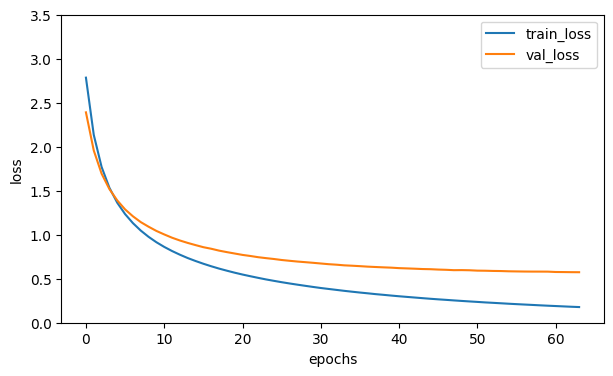

F1: 0.84875


In [62]:
plot_epoch_loss(history_mobileone_s4)
print(f"F1: {evaluate_f1_score(mobileone_s4)}")

In [63]:
# На память
torch.save({
    "epoch": 64,
    "model_state": mobileone_s4.state_dict(),
    "optimizer_state": optimizer.state_dict()
}, "mobileone_s4_checkpoint_64.pth")

Может, можно дообучить, понизив LR?

epoch:   0%|          | 0/64 [00:00<?, ?it/s]

loss 0.1717518098157366


epoch:   2%|▏         | 1/64 [01:34<1:38:43, 94.03s/it]


Epoch 001 train_loss: 0.1718     val_loss 0.5741 train_acc 0.9789 val_acc 0.8552
loss 0.17101756931756043


epoch:   3%|▎         | 2/64 [03:08<1:37:26, 94.30s/it]

...


Epoch 006 train_loss: 0.1694     val_loss 0.5735 train_acc 0.9792 val_acc 0.8552
loss 0.16903017302312412


epoch:  11%|█         | 7/64 [10:55<1:28:53, 93.57s/it]


Epoch 007 train_loss: 0.1690     val_loss 0.5735 train_acc 0.9793 val_acc 0.8548
loss 0.16863764276420382


epoch:  12%|█▎        | 8/64 [12:28<1:27:16, 93.50s/it]


Epoch 008 train_loss: 0.1686     val_loss 0.5734 train_acc 0.9796 val_acc 0.8546


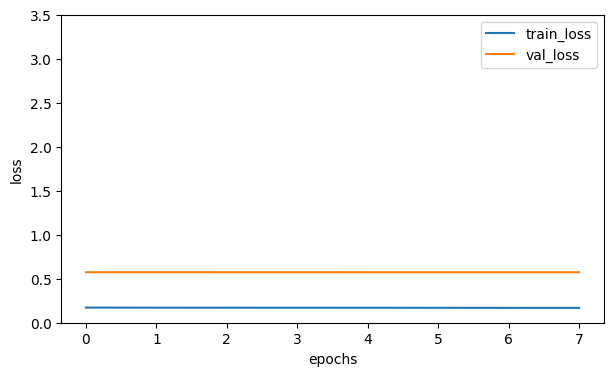

loss 0.16826199495425626


epoch:  14%|█▍        | 9/64 [14:03<1:25:55, 93.74s/it]


Epoch 009 train_loss: 0.1683     val_loss 0.5732 train_acc 0.9793 val_acc 0.8544
loss 0.16790243951566158


epoch:  16%|█▌        | 10/64 [15:36<1:24:14, 93.60s/it]


Epoch 010 train_loss: 0.1679     val_loss 0.5732 train_acc 0.9797 val_acc 0.8552
loss 0.1675265911968698


...


Epoch 014 train_loss: 0.1664     val_loss 0.5729 train_acc 0.9796 val_acc 0.8558
loss 0.16601466744923654


epoch:  23%|██▎       | 15/64 [23:33<1:17:16, 94.61s/it]


Epoch 015 train_loss: 0.1660     val_loss 0.5730 train_acc 0.9797 val_acc 0.8558
loss 0.16564398076254985


epoch:  25%|██▌       | 16/64 [25:11<1:16:29, 95.61s/it]


Epoch 016 train_loss: 0.1656     val_loss 0.5730 train_acc 0.9803 val_acc 0.8556


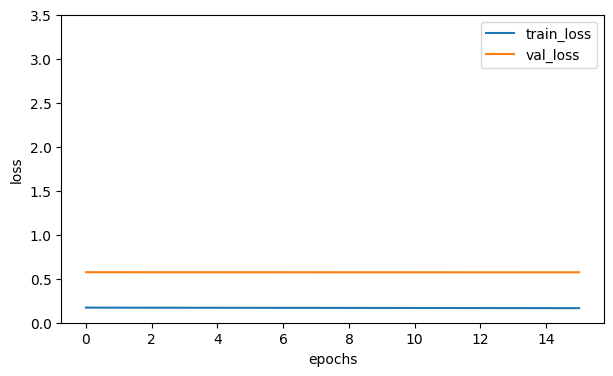

loss 0.16526103587608154


epoch:  27%|██▋       | 17/64 [26:50<1:15:46, 96.74s/it]


Epoch 017 train_loss: 0.1653     val_loss 0.5729 train_acc 0.9802 val_acc 0.8550
loss 0.1649020448876639


epoch:  28%|██▊       | 18/64 [28:30<1:14:52, 97.66s/it]


Epoch 018 train_loss: 0.1649     val_loss 0.5728 train_acc 0.9801 val_acc 0.8552
loss 0.16451977201803253


...


Epoch 022 train_loss: 0.1634     val_loss 0.5725 train_acc 0.9805 val_acc 0.8554
loss 0.16306566768459047


epoch:  36%|███▌      | 23/64 [36:48<1:07:08, 98.26s/it] 


Epoch 023 train_loss: 0.1631     val_loss 0.5727 train_acc 0.9806 val_acc 0.8554
loss 0.1626835144727357


epoch:  38%|███▊      | 24/64 [38:25<1:05:23, 98.09s/it]


Epoch 024 train_loss: 0.1627     val_loss 0.5724 train_acc 0.9806 val_acc 0.8548


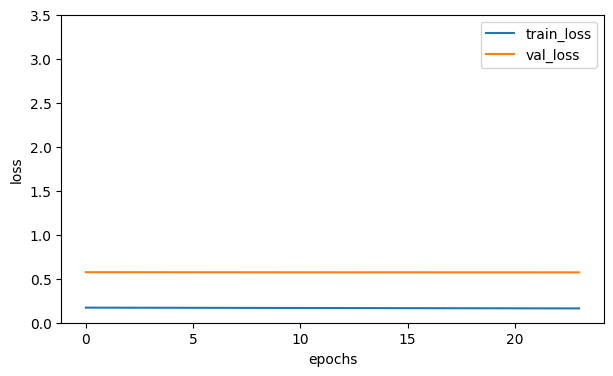

loss 0.16229117823027525


epoch:  39%|███▉      | 25/64 [40:05<1:04:00, 98.48s/it]


Epoch 025 train_loss: 0.1623     val_loss 0.5724 train_acc 0.9808 val_acc 0.8552
loss 0.16196941394987469


epoch:  41%|████      | 26/64 [41:38<1:01:20, 96.87s/it]


Epoch 026 train_loss: 0.1620     val_loss 0.5724 train_acc 0.9810 val_acc 0.8554
loss 0.1615689763117918


...


Epoch 030 train_loss: 0.1605     val_loss 0.5721 train_acc 0.9811 val_acc 0.8550
loss 0.16014392447969747


epoch:  48%|████▊     | 31/64 [49:30<52:52, 96.15s/it]


Epoch 031 train_loss: 0.1601     val_loss 0.5721 train_acc 0.9810 val_acc 0.8556
loss 0.1597666870587889


epoch:  50%|█████     | 32/64 [51:08<51:38, 96.82s/it]


Epoch 032 train_loss: 0.1598     val_loss 0.5720 train_acc 0.9813 val_acc 0.8552


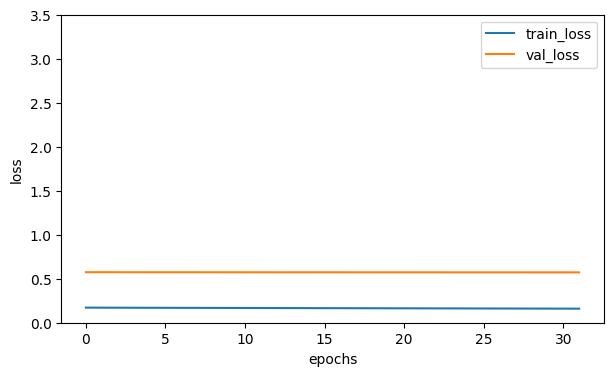

loss 0.1594329852378515


epoch:  52%|█████▏    | 33/64 [52:47<50:17, 97.34s/it]


Epoch 033 train_loss: 0.1594     val_loss 0.5717 train_acc 0.9813 val_acc 0.8554
loss 0.15906891957778704


epoch:  53%|█████▎    | 34/64 [54:28<49:13, 98.45s/it]


Epoch 034 train_loss: 0.1591     val_loss 0.5719 train_acc 0.9815 val_acc 0.8565
loss 0.15872904189328219


...


Epoch 038 train_loss: 0.1577     val_loss 0.5719 train_acc 0.9820 val_acc 0.8556
loss 0.1573045999979212


epoch:  61%|██████    | 39/64 [1:02:47<41:06, 98.66s/it]


Epoch 039 train_loss: 0.1573     val_loss 0.5720 train_acc 0.9820 val_acc 0.8554
loss 0.15694770599460972


epoch:  62%|██████▎   | 40/64 [1:04:27<39:31, 98.82s/it]


Epoch 040 train_loss: 0.1569     val_loss 0.5718 train_acc 0.9820 val_acc 0.8554


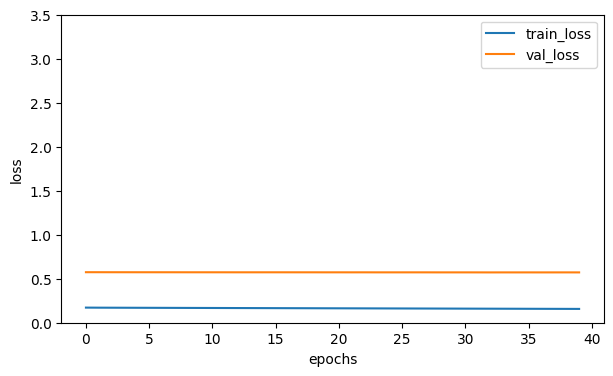

loss 0.15659885899801454


epoch:  64%|██████▍   | 41/64 [1:06:02<37:26, 97.68s/it]


Epoch 041 train_loss: 0.1566     val_loss 0.5716 train_acc 0.9818 val_acc 0.8554
loss 0.15625318615852218


epoch:  66%|██████▌   | 42/64 [1:07:32<34:59, 95.44s/it]


Epoch 042 train_loss: 0.1563     val_loss 0.5717 train_acc 0.9822 val_acc 0.8558
loss 0.15589125359365535


...


Epoch 046 train_loss: 0.1549     val_loss 0.5715 train_acc 0.9820 val_acc 0.8563
loss 0.1545250062213839


epoch:  73%|███████▎  | 47/64 [1:15:38<27:26, 96.88s/it]


Epoch 047 train_loss: 0.1545     val_loss 0.5714 train_acc 0.9825 val_acc 0.8558
loss 0.1541952113973023


epoch:  75%|███████▌  | 48/64 [1:17:11<25:32, 95.81s/it]


Epoch 048 train_loss: 0.1542     val_loss 0.5713 train_acc 0.9826 val_acc 0.8567


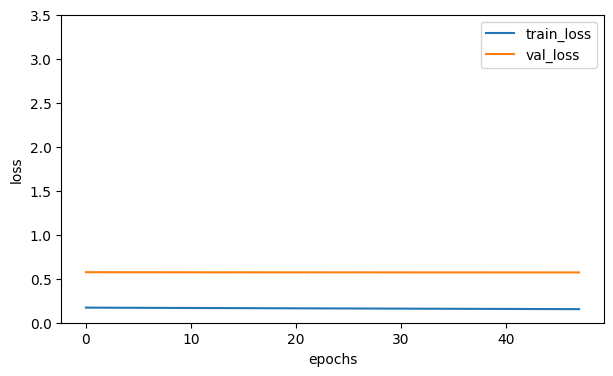

loss 0.15385147091256365


epoch:  77%|███████▋  | 49/64 [1:18:41<23:31, 94.13s/it]


Epoch 049 train_loss: 0.1539     val_loss 0.5714 train_acc 0.9826 val_acc 0.8559
loss 0.15349414574374012


epoch:  78%|███████▊  | 50/64 [1:20:14<21:52, 93.72s/it]


Epoch 050 train_loss: 0.1535     val_loss 0.5712 train_acc 0.9827 val_acc 0.8559
loss 0.15315296065485381


...


Epoch 054 train_loss: 0.1522     val_loss 0.5712 train_acc 0.9829 val_acc 0.8561
loss 0.15182273450573733


epoch:  86%|████████▌ | 55/64 [1:28:14<14:10, 94.53s/it]


Epoch 055 train_loss: 0.1518     val_loss 0.5713 train_acc 0.9829 val_acc 0.8559
loss 0.15146491426080647


epoch:  88%|████████▊ | 56/64 [1:29:49<12:38, 94.84s/it]


Epoch 056 train_loss: 0.1515     val_loss 0.5712 train_acc 0.9828 val_acc 0.8561


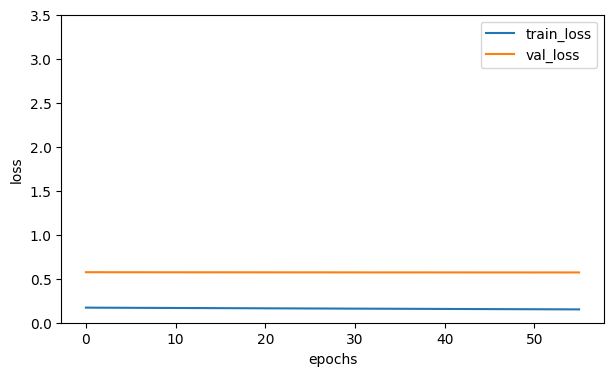

loss 0.15115049642040454


epoch:  89%|████████▉ | 57/64 [1:31:26<11:07, 95.31s/it]


Epoch 057 train_loss: 0.1512     val_loss 0.5710 train_acc 0.9832 val_acc 0.8558
loss 0.1508129747154128


epoch:  91%|█████████ | 58/64 [1:33:00<09:30, 95.06s/it]


Epoch 058 train_loss: 0.1508     val_loss 0.5711 train_acc 0.9832 val_acc 0.8561
loss 0.1504795870428268


...


Epoch 062 train_loss: 0.1495     val_loss 0.5710 train_acc 0.9833 val_acc 0.8558
loss 0.14915107475077927


epoch:  98%|█████████▊| 63/64 [1:40:52<01:34, 94.49s/it]


Epoch 063 train_loss: 0.1492     val_loss 0.5710 train_acc 0.9835 val_acc 0.8565
loss 0.14882672529498425


epoch: 100%|██████████| 64/64 [1:42:25<00:00, 94.07s/it]


Epoch 064 train_loss: 0.1488     val_loss 0.5708 train_acc 0.9838 val_acc 0.8559


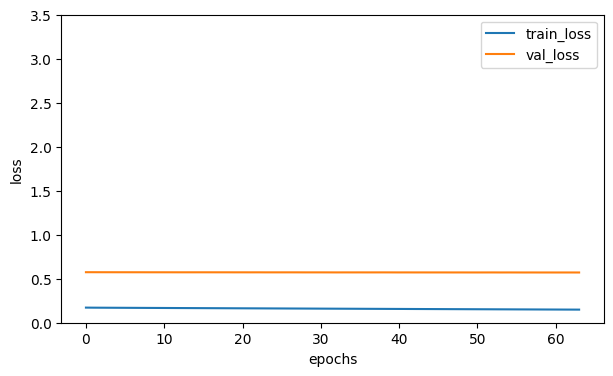

epoch: 100%|██████████| 64/64 [1:42:25<00:00, 96.02s/it]


In [66]:
optimizer = torch.optim.Adam(mobileone_s4.head.fc.parameters(), lr=1e-5)
history_mobileone_s4_2 = train(train_dataset, val_dataset, model=mobileone_s4, epochs=64, batch_size=64, optimizer=optimizer, cb_checkpoint=plot_epoch_loss)

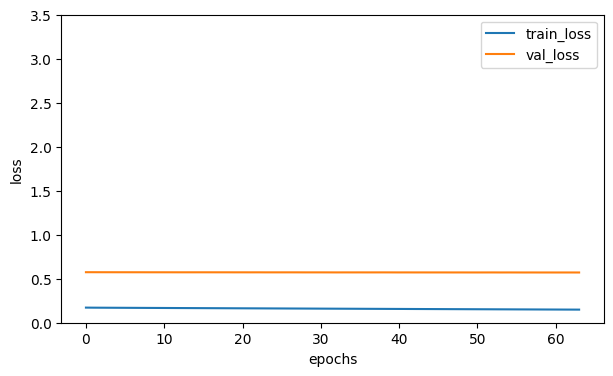

F1: 0.8625


In [68]:
plot_epoch_loss(history_mobileone_s4_2)
print(f"F1: {evaluate_f1_score(mobileone_s4)}")

Не то чтобы что-то сильно поменялось но +1 к F1 это +1 к F1

# Самое время вспомнить про первичный анализ данных
Может там куча невалидных примеров в выборке? Надо бы что-то подчистить.\

Я вручную просмотрел, что там странного. Здесь составляется список подозрительных файлов \ выбросов:
- Неправильные примеры персонажей
- Примеры где в кадре несколько персонажей
- Примеры где персонаж как бы тот, но в таком странном облике что лучше выкинуть (всякие "50 лет назад в чб он был таким")

In [85]:
# 20933 файла в обучающей выборке

outlier_data = [
    f"data/train/simpsons_dataset/abraham_grampa_simpson/pic_0002.jpg",
    f"data/train/simpsons_dataset/abraham_grampa_simpson/pic_0007.jpg",
    f"data/train/simpsons_dataset/abraham_grampa_simpson/pic_0008.jpg",
    f"data/train/simpsons_dataset/abraham_grampa_simpson/pic_0016.jpg",
    f"data/train/simpsons_dataset/abraham_grampa_simpson/pic_0052.jpg",
    f"data/train/simpsons_dataset/abraham_grampa_simpson/pic_0053.jpg",
    f"data/train/simpsons_dataset/abraham_grampa_simpson/pic_0090.jpg",
    f"data/train/simpsons_dataset/abraham_grampa_simpson/pic_0153.jpg",
    f"data/train/simpsons_dataset/abraham_grampa_simpson/pic_0141.jpg",
    f"data/train/simpsons_dataset/abraham_grampa_simpson/pic_0223.jpg",
    f"data/train/simpsons_dataset/abraham_grampa_simpson/pic_0242.jpg",
    f"data/train/simpsons_dataset/abraham_grampa_simpson/pic_0298.jpg",
    f"data/train/simpsons_dataset/abraham_grampa_simpson/pic_0364.jpg",
    f"data/train/simpsons_dataset/abraham_grampa_simpson/pic_0418.jpg",
    f"data/train/simpsons_dataset/abraham_grampa_simpson/pic_0471.jpg",
    f"data/train/simpsons_dataset/abraham_grampa_simpson/pic_0549.jpg",
    f"data/train/simpsons_dataset/abraham_grampa_simpson/pic_0563.jpg",
    f"data/train/simpsons_dataset/abraham_grampa_simpson/pic_0564.jpg",
    f"data/train/simpsons_dataset/abraham_grampa_simpson/pic_0565.jpg",
    f"data/train/simpsons_dataset/abraham_grampa_simpson/pic_0566.jpg",
    f"data/train/simpsons_dataset/abraham_grampa_simpson/pic_0705.jpg",
    f"data/train/simpsons_dataset/abraham_grampa_simpson/pic_0890.jpg",
    f"data/train/simpsons_dataset/agnes_skinner/pic_0015.jpg",
    f"data/train/simpsons_dataset/apu_nahasapeemapetilon/pic_0090.jpg",
    f"data/train/simpsons_dataset/apu_nahasapeemapetilon/pic_0178.jpg",
    f"data/train/simpsons_dataset/apu_nahasapeemapetilon/pic_0224.jpg",
    f"data/train/simpsons_dataset/apu_nahasapeemapetilon/pic_0322.jpg",
    f"data/train/simpsons_dataset/apu_nahasapeemapetilon/pic_0401.jpg",
    f"data/train/simpsons_dataset/apu_nahasapeemapetilon/pic_0505.jpg",
    f"data/train/simpsons_dataset/apu_nahasapeemapetilon/pic_0507.jpg",
    f"data/train/simpsons_dataset/apu_nahasapeemapetilon/pic_0509.jpg",
    f"data/train/simpsons_dataset/apu_nahasapeemapetilon/pic_0526.jpg",
    f"data/train/simpsons_dataset/apu_nahasapeemapetilon/pic_0554.jpg",
    f"data/train/simpsons_dataset/apu_nahasapeemapetilon/pic_0548.jpg",
    f"data/train/simpsons_dataset/apu_nahasapeemapetilon/pic_0617.jpg",
    f"data/train/simpsons_dataset/barney_gumble/pic_0086.jpg",
    f"data/train/simpsons_dataset/barney_gumble/pic_0083.jpg",
    f"data/train/simpsons_dataset/barney_gumble/pic_0056.jpg",
    f"data/train/simpsons_dataset/barney_gumble/pic_0049.jpg",
    f"data/train/simpsons_dataset/bart_simpson/pic_0015.jpg",
    f"data/train/simpsons_dataset/bart_simpson/pic_0069.jpg",
    f"data/train/simpsons_dataset/bart_simpson/pic_1328.jpg",
    f"data/train/simpsons_dataset/bart_simpson/pic_1329.jpg",
    f"data/train/simpsons_dataset/bart_simpson/pic_1330.jpg",
    f"data/train/simpsons_dataset/bart_simpson/pic_1338.jpg",
    f"data/train/simpsons_dataset/bart_simpson/pic_0712.jpg",
    f"data/train/simpsons_dataset/carl_carlson/pic_0022.jpg",
    f"data/train/simpsons_dataset/carl_carlson/pic_0033.jpg",
    f"data/train/simpsons_dataset/carl_carlson/pic_0028.jpg",
    f"data/train/simpsons_dataset/carl_carlson/pic_0091.jpg",
    f"data/train/simpsons_dataset/charles_montgomery_burns/pic_0122.jpg",
    f"data/train/simpsons_dataset/charles_montgomery_burns/pic_0132.jpg",
    f"data/train/simpsons_dataset/charles_montgomery_burns/pic_0176.jpg",
    f"data/train/simpsons_dataset/charles_montgomery_burns/pic_0185.jpg",
    f"data/train/simpsons_dataset/charles_montgomery_burns/pic_0177.jpg",
    f"data/train/simpsons_dataset/charles_montgomery_burns/pic_0326.jpg",
    f"data/train/simpsons_dataset/charles_montgomery_burns/pic_0374.jpg",
    f"data/train/simpsons_dataset/charles_montgomery_burns/pic_0485.jpg",
    f"data/train/simpsons_dataset/charles_montgomery_burns/pic_0488.jpg",
    f"data/train/simpsons_dataset/charles_montgomery_burns/pic_0601.jpg",
    f"data/train/simpsons_dataset/charles_montgomery_burns/pic_1052.jpg",
    f"data/train/simpsons_dataset/charles_montgomery_burns/pic_1055.jpg",
    f"data/train/simpsons_dataset/charles_montgomery_burns/pic_1154.jpg",
    f"data/train/simpsons_dataset/chief_wiggum/pic_0019.jpg",
    f"data/train/simpsons_dataset/chief_wiggum/pic_0057.jpg",
    f"data/train/simpsons_dataset/chief_wiggum/pic_0113.jpg",
    f"data/train/simpsons_dataset/chief_wiggum/pic_0114.jpg",
    f"data/train/simpsons_dataset/chief_wiggum/pic_0164.jpg",
    f"data/train/simpsons_dataset/chief_wiggum/pic_0069.jpg",
    f"data/train/simpsons_dataset/chief_wiggum/pic_0257.jpg",
    f"data/train/simpsons_dataset/chief_wiggum/pic_0258.jpg",
    f"data/train/simpsons_dataset/chief_wiggum/pic_0388.jpg",
    f"data/train/simpsons_dataset/chief_wiggum/pic_0383.jpg",
    f"data/train/simpsons_dataset/chief_wiggum/pic_0381.jpg",
    f"data/train/simpsons_dataset/chief_wiggum/pic_0380.jpg",
    f"data/train/simpsons_dataset/chief_wiggum/pic_0461.jpg",
    f"data/train/simpsons_dataset/chief_wiggum/pic_0473.jpg",
    f"data/train/simpsons_dataset/chief_wiggum/pic_0478.jpg",
    f"data/train/simpsons_dataset/chief_wiggum/pic_0482.jpg",
    f"data/train/simpsons_dataset/chief_wiggum/pic_0487.jpg",
    f"data/train/simpsons_dataset/chief_wiggum/pic_0508.jpg",
    f"data/train/simpsons_dataset/chief_wiggum/pic_0564.jpg",
    f"data/train/simpsons_dataset/chief_wiggum/pic_0656.jpg",
    f"data/train/simpsons_dataset/chief_wiggum/pic_0779.jpg",
    f"data/train/simpsons_dataset/chief_wiggum/pic_0780.jpg",
    f"data/train/simpsons_dataset/chief_wiggum/pic_0787.jpg",
    f"data/train/simpsons_dataset/chief_wiggum/pic_0788.jpg",
    f"data/train/simpsons_dataset/chief_wiggum/pic_0973.jpg",
    f"data/train/simpsons_dataset/cletus_spuckler/pic_0014.jpg",
    f"data/train/simpsons_dataset/cletus_spuckler/pic_0015.jpg",
    f"data/train/simpsons_dataset/cletus_spuckler/pic_0046.jpg",
    f"data/train/simpsons_dataset/cletus_spuckler/pic_0033.jpg",
    f"data/train/simpsons_dataset/cletus_spuckler/pic_0022.jpg",
    f"data/train/simpsons_dataset/comic_book_guy/pic_0020.jpg",
    f"data/train/simpsons_dataset/comic_book_guy/pic_0027.jpg",
    f"data/train/simpsons_dataset/comic_book_guy/pic_0034.jpg",
    f"data/train/simpsons_dataset/comic_book_guy/pic_0200.jpg",
    f"data/train/simpsons_dataset/comic_book_guy/pic_0457.jpg",
    f"data/train/simpsons_dataset/comic_book_guy/pic_0263.jpg",
    f"data/train/simpsons_dataset/edna_krabappel/pic_0003.jpg",
    f"data/train/simpsons_dataset/edna_krabappel/pic_0021.jpg",
    f"data/train/simpsons_dataset/edna_krabappel/pic_0210.jpg",
    f"data/train/simpsons_dataset/edna_krabappel/pic_0425.jpg",
    f"data/train/simpsons_dataset/groundskeeper_willie/pic_0008.jpg",
    f"data/train/simpsons_dataset/groundskeeper_willie/pic_0069.jpg",
    f"data/train/simpsons_dataset/homer_simpson/pic_0002.jpg",
    f"data/train/simpsons_dataset/homer_simpson/pic_0008.jpg",
    f"data/train/simpsons_dataset/homer_simpson/pic_0026.jpg",
    f"data/train/simpsons_dataset/homer_simpson/pic_0171.jpg",
    f"data/train/simpsons_dataset/homer_simpson/pic_0269.jpg",
    f"data/train/simpsons_dataset/homer_simpson/pic_0263.jpg",
    f"data/train/simpsons_dataset/homer_simpson/pic_0385.jpg",
    f"data/train/simpsons_dataset/homer_simpson/pic_0373.jpg",
    f"data/train/simpsons_dataset/homer_simpson/pic_0416.jpg",
    f"data/train/simpsons_dataset/homer_simpson/pic_0720.jpg",
    f"data/train/simpsons_dataset/homer_simpson/pic_0922.jpg",
    f"data/train/simpsons_dataset/homer_simpson/pic_1238.jpg",
    f"data/train/simpsons_dataset/homer_simpson/pic_1308.jpg",
    f"data/train/simpsons_dataset/homer_simpson/pic_1391.jpg",
    f"data/train/simpsons_dataset/homer_simpson/pic_1957.jpg",
    f"data/train/simpsons_dataset/homer_simpson/pic_2226.jpg",
    f"data/train/simpsons_dataset/homer_simpson/pic_2227.jpg",
    f"data/train/simpsons_dataset/homer_simpson/pic_2232.jpg",
    f"data/train/simpsons_dataset/homer_simpson/pic_2233.jpg",
    f"data/train/simpsons_dataset/homer_simpson/pic_2234.jpg",
    f"data/train/simpsons_dataset/homer_simpson/pic_2235.jpg",
    f"data/train/simpsons_dataset/homer_simpson/pic_2243.jpg",
    f"data/train/simpsons_dataset/homer_simpson/pic_2245.jpg",
    f"data/train/simpsons_dataset/kent_brockman/pic_0045.jpg",
    f"data/train/simpsons_dataset/kent_brockman/pic_0494.jpg",
    f"data/train/simpsons_dataset/kent_brockman/pic_0495.jpg",
    f"data/train/simpsons_dataset/kent_brockman/pic_0077.jpg",
    f"data/train/simpsons_dataset/krusty_the_clown/pic_0003.jpg",
    f"data/train/simpsons_dataset/krusty_the_clown/pic_0344.jpg",
    f"data/train/simpsons_dataset/krusty_the_clown/pic_0346.jpg",
    f"data/train/simpsons_dataset/krusty_the_clown/pic_0439.jpg",
    f"data/train/simpsons_dataset/krusty_the_clown/pic_0440.jpg",
    f"data/train/simpsons_dataset/krusty_the_clown/pic_0441.jpg",
    f"data/train/simpsons_dataset/krusty_the_clown/pic_0442.jpg",
    f"data/train/simpsons_dataset/krusty_the_clown/pic_0443.jpg",
    f"data/train/simpsons_dataset/krusty_the_clown/pic_0444.jpg",
    f"data/train/simpsons_dataset/krusty_the_clown/pic_0446.jpg",
    f"data/train/simpsons_dataset/krusty_the_clown/pic_0511.jpg",
    f"data/train/simpsons_dataset/krusty_the_clown/pic_0608.jpg",
    f"data/train/simpsons_dataset/krusty_the_clown/pic_0638.jpg",
    f"data/train/simpsons_dataset/krusty_the_clown/pic_0644.jpg",
    f"data/train/simpsons_dataset/krusty_the_clown/pic_0696.jpg",
    f"data/train/simpsons_dataset/krusty_the_clown/pic_0694.jpg",
    f"data/train/simpsons_dataset/krusty_the_clown/pic_0707.jpg",
    f"data/train/simpsons_dataset/krusty_the_clown/pic_0738.jpg",
    f"data/train/simpsons_dataset/krusty_the_clown/pic_0739.jpg",
    f"data/train/simpsons_dataset/krusty_the_clown/pic_0756.jpg",
    f"data/train/simpsons_dataset/krusty_the_clown/pic_0802.jpg",
    f"data/train/simpsons_dataset/krusty_the_clown/pic_0918.jpg",
    f"data/train/simpsons_dataset/krusty_the_clown/pic_1042.jpg",
    f"data/train/simpsons_dataset/krusty_the_clown/pic_1158.jpg",
    f"data/train/simpsons_dataset/lenny_leonard/pic_0056.jpg",
    f"data/train/simpsons_dataset/lenny_leonard/pic_0246.jpg",
    f"data/train/simpsons_dataset/lisa_simpson/pic_0002.jpg",
    f"data/train/simpsons_dataset/lisa_simpson/pic_0015.jpg",
    f"data/train/simpsons_dataset/lisa_simpson/pic_0407.jpg",
    f"data/train/simpsons_dataset/lisa_simpson/pic_0705.jpg",
    f"data/train/simpsons_dataset/lisa_simpson/pic_1089.jpg",
    f"data/train/simpsons_dataset/lisa_simpson/pic_1105.jpg",
    f"data/train/simpsons_dataset/lisa_simpson/pic_0542.jpg",
    f"data/train/simpsons_dataset/maggie_simpson/pic_0031.jpg",
    f"data/train/simpsons_dataset/maggie_simpson/pic_0104.jpg",
    f"data/train/simpsons_dataset/marge_simpson/pic_0008.jpg",
    f"data/train/simpsons_dataset/marge_simpson/pic_0009.jpg",
    f"data/train/simpsons_dataset/marge_simpson/pic_0032.jpg",
    f"data/train/simpsons_dataset/marge_simpson/pic_0026.jpg",
    f"data/train/simpsons_dataset/marge_simpson/pic_0044.jpg",
    f"data/train/simpsons_dataset/marge_simpson/pic_0538.jpg",
    f"data/train/simpsons_dataset/marge_simpson/pic_0663.jpg",
    f"data/train/simpsons_dataset/marge_simpson/pic_0784.jpg",
    f"data/train/simpsons_dataset/marge_simpson/pic_0944.jpg",
    f"data/train/simpsons_dataset/marge_simpson/pic_0952.jpg",
    f"data/train/simpsons_dataset/marge_simpson/pic_1000.jpg",
    f"data/train/simpsons_dataset/marge_simpson/pic_1273.jpg",
    f"data/train/simpsons_dataset/martin_prince/pic_0010.jpg",
    f"data/train/simpsons_dataset/martin_prince/pic_0008.jpg",
    f"data/train/simpsons_dataset/mayor_quimby/pic_0037.jpg",
    f"data/train/simpsons_dataset/mayor_quimby/pic_0032.jpg",
    f"data/train/simpsons_dataset/mayor_quimby/pic_0140.jpg",
    f"data/train/simpsons_dataset/mayor_quimby/pic_0168.jpg",
    f"data/train/simpsons_dataset/mayor_quimby/pic_0240.jpg",
    f"data/train/simpsons_dataset/mayor_quimby/pic_0241.jpg",
    f"data/train/simpsons_dataset/mayor_quimby/pic_0104.jpg",
    f"data/train/simpsons_dataset/milhouse_van_houten/pic_0294.jpg",
    f"data/train/simpsons_dataset/milhouse_van_houten/pic_0296.jpg",
    f"data/train/simpsons_dataset/milhouse_van_houten/pic_0307.jpg",
    f"data/train/simpsons_dataset/milhouse_van_houten/pic_0539.jpg",
    f"data/train/simpsons_dataset/milhouse_van_houten/pic_0818.jpg",
    f"data/train/simpsons_dataset/milhouse_van_houten/pic_0823.jpg",
    f"data/train/simpsons_dataset/milhouse_van_houten/pic_0868.jpg",
    f"data/train/simpsons_dataset/milhouse_van_houten/pic_0969.jpg",
    f"data/train/simpsons_dataset/milhouse_van_houten/pic_1079.jpg",
    f"data/train/simpsons_dataset/miss_hoover/pic_0009.jpg",
    f"data/train/simpsons_dataset/moe_szyslak/pic_0030.jpg",
    f"data/train/simpsons_dataset/moe_szyslak/pic_0180.jpg",
    f"data/train/simpsons_dataset/moe_szyslak/pic_0376.jpg",
    f"data/train/simpsons_dataset/moe_szyslak/pic_0657.jpg",
    f"data/train/simpsons_dataset/moe_szyslak/pic_0768.jpg",
    f"data/train/simpsons_dataset/moe_szyslak/pic_0966.jpg",
    f"data/train/simpsons_dataset/moe_szyslak/pic_1025.jpg",
    f"data/train/simpsons_dataset/moe_szyslak/pic_1028.jpg",
    f"data/train/simpsons_dataset/moe_szyslak/pic_1092.jpg",
    f"data/train/simpsons_dataset/moe_szyslak/pic_1247.jpg",
    f"data/train/simpsons_dataset/moe_szyslak/pic_1373.jpg",
    f"data/train/simpsons_dataset/moe_szyslak/pic_1371.jpg",
    f"data/train/simpsons_dataset/moe_szyslak/pic_1439.jpg",
    f"data/train/simpsons_dataset/moe_szyslak/pic_1444.jpg",
    f"data/train/simpsons_dataset/ned_flanders/pic_0005.jpg",
    f"data/train/simpsons_dataset/ned_flanders/pic_0129.jpg",
    f"data/train/simpsons_dataset/ned_flanders/pic_0111.jpg",
    f"data/train/simpsons_dataset/ned_flanders/pic_0112.jpg",
    f"data/train/simpsons_dataset/ned_flanders/pic_0143.jpg",
    f"data/train/simpsons_dataset/ned_flanders/pic_0136.jpg",
    f"data/train/simpsons_dataset/ned_flanders/pic_0127.jpg",
    f"data/train/simpsons_dataset/ned_flanders/pic_0242.jpg",
    f"data/train/simpsons_dataset/ned_flanders/pic_0345.jpg",
    f"data/train/simpsons_dataset/ned_flanders/pic_0344.jpg",
    f"data/train/simpsons_dataset/ned_flanders/pic_0336.jpg",
    f"data/train/simpsons_dataset/ned_flanders/pic_0349.jpg",
    f"data/train/simpsons_dataset/ned_flanders/pic_0350.jpg",
    f"data/train/simpsons_dataset/ned_flanders/pic_0358.jpg",
    f"data/train/simpsons_dataset/ned_flanders/pic_0357.jpg",
    f"data/train/simpsons_dataset/ned_flanders/pic_0354.jpg",
    f"data/train/simpsons_dataset/ned_flanders/pic_0352.jpg",
    f"data/train/simpsons_dataset/ned_flanders/pic_0466.jpg",
    f"data/train/simpsons_dataset/ned_flanders/pic_0516.jpg",
    f"data/train/simpsons_dataset/ned_flanders/pic_0622.jpg",
    f"data/train/simpsons_dataset/ned_flanders/pic_0706.jpg",
    f"data/train/simpsons_dataset/ned_flanders/pic_0704.jpg",
    f"data/train/simpsons_dataset/ned_flanders/pic_0856.jpg",
    f"data/train/simpsons_dataset/ned_flanders/pic_0857.jpg",
    f"data/train/simpsons_dataset/ned_flanders/pic_1032.jpg",
    f"data/train/simpsons_dataset/ned_flanders/pic_1298.jpg",
    f"data/train/simpsons_dataset/ned_flanders/pic_1437.jpg",
    f"data/train/simpsons_dataset/ned_flanders/pic_1444.jpg",
    f"data/train/simpsons_dataset/ned_flanders/pic_1447.jpg",
    f"data/train/simpsons_dataset/nelson_muntz/pic_0013.jpg",
    f"data/train/simpsons_dataset/nelson_muntz/pic_0032.jpg",
    f"data/train/simpsons_dataset/nelson_muntz/pic_0131.jpg",
    f"data/train/simpsons_dataset/nelson_muntz/pic_0134.jpg",
    f"data/train/simpsons_dataset/nelson_muntz/pic_0141.jpg",
    f"data/train/simpsons_dataset/nelson_muntz/pic_0208.jpg",
    f"data/train/simpsons_dataset/nelson_muntz/pic_0224.jpg",
    f"data/train/simpsons_dataset/nelson_muntz/pic_0336.jpg",
    f"data/train/simpsons_dataset/nelson_muntz/pic_0343.jpg",
    f"data/train/simpsons_dataset/nelson_muntz/pic_0350.jpg",
    f"data/train/simpsons_dataset/nelson_muntz/pic_0349.jpg",
    f"data/train/simpsons_dataset/nelson_muntz/pic_0357.jpg",
    f"data/train/simpsons_dataset/patty_bouvier/pic_0067.jpg",
    f"data/train/simpsons_dataset/patty_bouvier/pic_0066.jpg",
    f"data/train/simpsons_dataset/patty_bouvier/pic_0000.jpg",
    f"data/train/simpsons_dataset/principal_skinner/pic_0134.jpg",
    f"data/train/simpsons_dataset/principal_skinner/pic_0130.jpg",
    f"data/train/simpsons_dataset/principal_skinner/pic_0148.jpg",
    f"data/train/simpsons_dataset/principal_skinner/pic_0158.jpg",
    f"data/train/simpsons_dataset/principal_skinner/pic_0455.jpg",
    f"data/train/simpsons_dataset/principal_skinner/pic_0591.jpg",
    f"data/train/simpsons_dataset/principal_skinner/pic_0702.jpg",
    f"data/train/simpsons_dataset/principal_skinner/pic_0716.jpg",
    f"data/train/simpsons_dataset/principal_skinner/pic_0812.jpg",
    f"data/train/simpsons_dataset/principal_skinner/pic_0877.jpg",
    f"data/train/simpsons_dataset/principal_skinner/pic_0879.jpg",
    f"data/train/simpsons_dataset/principal_skinner/pic_1015.jpg",
    f"data/train/simpsons_dataset/principal_skinner/pic_1015.jpg",
    f"data/train/simpsons_dataset/professor_john_frink/pic_0031.jpg",
    f"data/train/simpsons_dataset/professor_john_frink/pic_0034.jpg",
    f"data/train/simpsons_dataset/professor_john_frink/pic_0029.jpg",
    f"data/train/simpsons_dataset/professor_john_frink/pic_0064.jpg",
    f"data/train/simpsons_dataset/ralph_wiggum/pic_0034.jpg",
    f"data/train/simpsons_dataset/ralph_wiggum/pic_0083.jpg",
    f"data/train/simpsons_dataset/ralph_wiggum/pic_0084.jpg",
    f"data/train/simpsons_dataset/sideshow_bob/pic_0012.jpg",
    f"data/train/simpsons_dataset/sideshow_bob/pic_0039.jpg",
    f"data/train/simpsons_dataset/sideshow_bob/pic_0122.jpg",
    f"data/train/simpsons_dataset/sideshow_bob/pic_0128.jpg",
    f"data/train/simpsons_dataset/sideshow_bob/pic_0189.jpg",
    f"data/train/simpsons_dataset/sideshow_bob/pic_0246.jpg",
    f"data/train/simpsons_dataset/sideshow_bob/pic_0228.jpg",
    f"data/train/simpsons_dataset/sideshow_bob/pic_0221.jpg",
    f"data/train/simpsons_dataset/sideshow_bob/pic_0212.jpg",
    f"data/train/simpsons_dataset/sideshow_bob/pic_0215.jpg",
    f"data/train/simpsons_dataset/sideshow_bob/pic_0418.jpg",
    f"data/train/simpsons_dataset/sideshow_bob/pic_0408.jpg",
    f"data/train/simpsons_dataset/sideshow_bob/pic_0566.jpg",
    f"data/train/simpsons_dataset/sideshow_bob/pic_0760.jpg",
    f"data/train/simpsons_dataset/sideshow_bob/pic_0593.jpg",
    f"data/train/simpsons_dataset/sideshow_bob/pic_0261.jpg",
    f"data/train/simpsons_dataset/sideshow_mel/pic_0014.jpg",
    f"data/train/simpsons_dataset/sideshow_mel/pic_0034.jpg",
    f"data/train/simpsons_dataset/sideshow_mel/pic_0032.jpg",
    f"data/train/simpsons_dataset/sideshow_mel/pic_0002.jpg",
    f"data/train/simpsons_dataset/sideshow_mel/pic_0003.jpg",
    f"data/train/simpsons_dataset/sideshow_mel/pic_0025.jpg",
    f"data/train/simpsons_dataset/sideshow_mel/pic_0022.jpg",
    f"data/train/simpsons_dataset/waylon_smithers/pic_0027.jpg",
]

In [86]:
from pathlib import Path

print(f"Delete {len(outlier_data)} outliers")

for path in outlier_data:
    Path(path).unlink(missing_ok=True)

Delete 300 outliers


После удаления выборосов попробуем перетюнить с нуля неплохую модель mobileone_s4

In [89]:
mobileone_s4_without_outliers = timm.create_model("mobileone_s4.apple_in1k", pretrained=True)
mobileone_s4_without_outliers = mobileone_s4_without_outliers.to(DEVICE)

num_features = mobileone_s4_without_outliers.head.fc.in_features
mobileone_s4_without_outliers.head.fc = torch.nn.Linear(num_features, n_classes).to(DEVICE)

for p in mobileone_s4_without_outliers.parameters():
    p.requires_grad = False

for p in mobileone_s4_without_outliers.head.fc.parameters():
    p.requires_grad = True

optimizer = torch.optim.Adam(mobileone_s4_without_outliers.head.fc.parameters(), lr=1e-4)

epoch:   0%|          | 0/96 [00:00<?, ?it/s]

loss 2.799460096205186


epoch:   1%|          | 1/96 [01:52<2:58:05, 112.48s/it]


Epoch 001 train_loss: 2.7995     val_loss 2.4000 train_acc 0.2821 val_acc 0.4796
loss 2.1429469959339147


epoch:   2%|▏         | 2/96 [03:33<2:45:24, 105.58s/it]

...


Epoch 006 train_loss: 1.2368     val_loss 1.2659 train_acc 0.7262 val_acc 0.7112
loss 1.1322973444773807


epoch:   7%|▋         | 7/96 [11:38<2:24:32, 97.44s/it]


Epoch 007 train_loss: 1.1323     val_loss 1.1843 train_acc 0.7500 val_acc 0.7273
loss 1.0472462095428554


epoch:   8%|▊         | 8/96 [13:13<2:21:52, 96.74s/it]


Epoch 008 train_loss: 1.0472     val_loss 1.1168 train_acc 0.7661 val_acc 0.7360


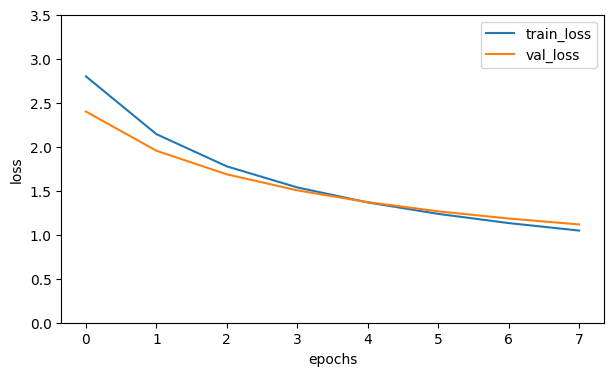

loss 0.9750780148536978


epoch:   9%|▉         | 9/96 [14:48<2:19:22, 96.12s/it]


Epoch 009 train_loss: 0.9751     val_loss 1.0594 train_acc 0.7822 val_acc 0.7517
loss 0.9125676254771637


epoch:  10%|█         | 10/96 [16:19<2:15:32, 94.56s/it]


Epoch 010 train_loss: 0.9126     val_loss 1.0111 train_acc 0.7977 val_acc 0.7602
loss 0.8590759187676795


...


Epoch 014 train_loss: 0.7305     val_loss 0.8698 train_acc 0.8401 val_acc 0.7916
loss 0.696485382054657


epoch:  16%|█▌        | 15/96 [24:22<2:14:05, 99.32s/it]


Epoch 015 train_loss: 0.6965     val_loss 0.8432 train_acc 0.8465 val_acc 0.7986
loss 0.6646790904798492


epoch:  17%|█▋        | 16/96 [25:53<2:09:13, 96.92s/it]


Epoch 016 train_loss: 0.6647     val_loss 0.8189 train_acc 0.8549 val_acc 0.8046


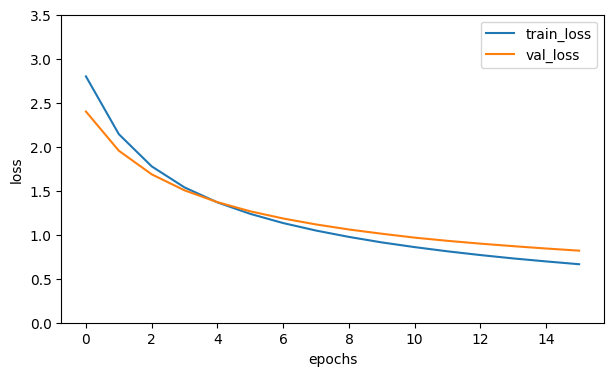

loss 0.6354545010349477


epoch:  18%|█▊        | 17/96 [27:27<2:06:10, 95.83s/it]


Epoch 017 train_loss: 0.6355     val_loss 0.7987 train_acc 0.8612 val_acc 0.8097
loss 0.6092749465262948


epoch:  19%|█▉        | 18/96 [29:23<2:12:28, 101.91s/it]


Epoch 018 train_loss: 0.6093     val_loss 0.7777 train_acc 0.8680 val_acc 0.8141
loss 0.584625466124114


...


Epoch 022 train_loss: 0.5206     val_loss 0.7151 train_acc 0.8907 val_acc 0.8275
loss 0.5019681425645394


epoch:  24%|██▍       | 23/96 [37:05<1:54:12, 93.88s/it]


Epoch 023 train_loss: 0.5020     val_loss 0.7038 train_acc 0.8963 val_acc 0.8285
loss 0.4849159669221314


epoch:  25%|██▌       | 24/96 [38:37<1:51:51, 93.21s/it]


Epoch 024 train_loss: 0.4849     val_loss 0.6914 train_acc 0.9000 val_acc 0.8294


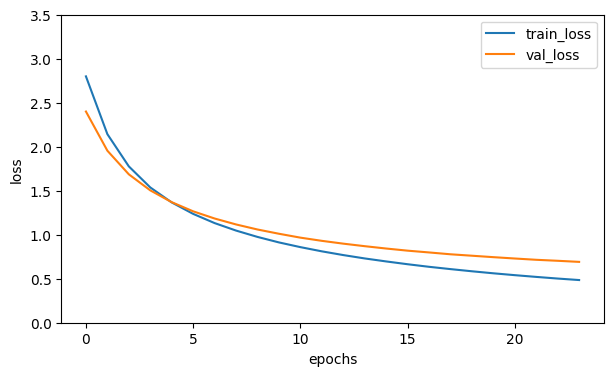

loss 0.4684466264475143


epoch:  26%|██▌       | 25/96 [40:09<1:49:49, 92.80s/it]


Epoch 025 train_loss: 0.4684     val_loss 0.6808 train_acc 0.9041 val_acc 0.8306
loss 0.4526618052068165


epoch:  27%|██▋       | 26/96 [41:40<1:47:49, 92.42s/it]


Epoch 026 train_loss: 0.4527     val_loss 0.6717 train_acc 0.9081 val_acc 0.8339
loss 0.43803170077442544


...


Epoch 030 train_loss: 0.3983     val_loss 0.6346 train_acc 0.9234 val_acc 0.8420
loss 0.3863083679148377


epoch:  32%|███▏      | 31/96 [49:52<1:47:47, 99.50s/it]


Epoch 031 train_loss: 0.3863     val_loss 0.6294 train_acc 0.9266 val_acc 0.8422
loss 0.37485795389469684


epoch:  33%|███▎      | 32/96 [51:24<1:43:42, 97.23s/it]


Epoch 032 train_loss: 0.3749     val_loss 0.6225 train_acc 0.9282 val_acc 0.8416


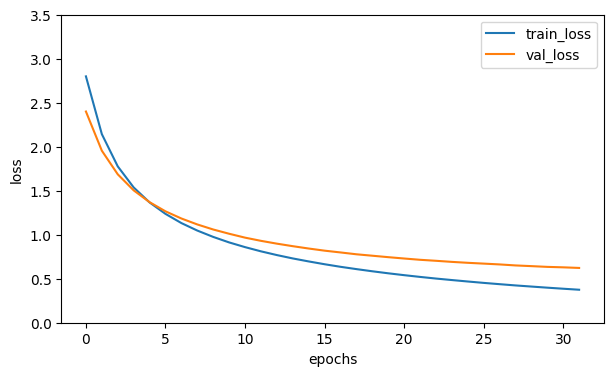

loss 0.36445195664111557


epoch:  34%|███▍      | 33/96 [52:55<1:40:09, 95.39s/it]


Epoch 033 train_loss: 0.3645     val_loss 0.6155 train_acc 0.9314 val_acc 0.8436
loss 0.35441736851543526


epoch:  35%|███▌      | 34/96 [54:26<1:37:15, 94.13s/it]


Epoch 034 train_loss: 0.3544     val_loss 0.6091 train_acc 0.9339 val_acc 0.8490
loss 0.3441099118743459


...


Epoch 038 train_loss: 0.3170     val_loss 0.5885 train_acc 0.9416 val_acc 0.8492
loss 0.30859691809953127


epoch:  41%|████      | 39/96 [1:01:58<1:26:10, 90.71s/it]


Epoch 039 train_loss: 0.3086     val_loss 0.5853 train_acc 0.9437 val_acc 0.8496
loss 0.30057675677085344


epoch:  42%|████▏     | 40/96 [1:03:27<1:24:05, 90.09s/it]


Epoch 040 train_loss: 0.3006     val_loss 0.5817 train_acc 0.9459 val_acc 0.8502


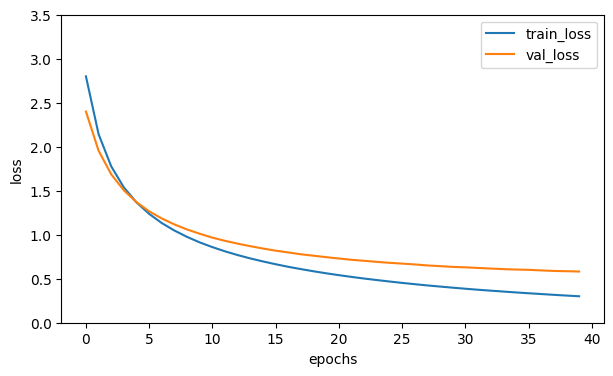

loss 0.292857351958848


epoch:  43%|████▎     | 41/96 [1:04:56<1:22:23, 89.88s/it]


Epoch 041 train_loss: 0.2929     val_loss 0.5759 train_acc 0.9473 val_acc 0.8511
loss 0.28520288562928725


epoch:  44%|████▍     | 42/96 [1:06:26<1:20:55, 89.91s/it]


Epoch 042 train_loss: 0.2852     val_loss 0.5726 train_acc 0.9494 val_acc 0.8517
loss 0.2780296132098492


...


Epoch 046 train_loss: 0.2582     val_loss 0.5599 train_acc 0.9541 val_acc 0.8560
loss 0.2520772259840095


epoch:  49%|████▉     | 47/96 [1:13:51<1:12:51, 89.22s/it]


Epoch 047 train_loss: 0.2521     val_loss 0.5568 train_acc 0.9572 val_acc 0.8558
loss 0.24597060499264467


epoch:  50%|█████     | 48/96 [1:15:20<1:11:17, 89.11s/it]


Epoch 048 train_loss: 0.2460     val_loss 0.5552 train_acc 0.9580 val_acc 0.8562


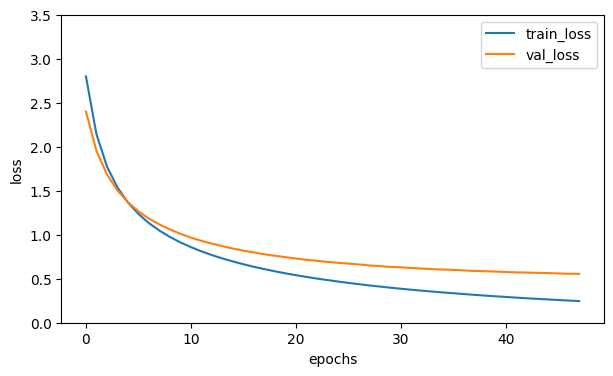

loss 0.24005877900585798


epoch:  51%|█████     | 49/96 [1:16:49<1:09:46, 89.07s/it]


Epoch 049 train_loss: 0.2401     val_loss 0.5514 train_acc 0.9583 val_acc 0.8573
loss 0.23438444979260156


epoch:  52%|█████▏    | 50/96 [1:18:18<1:08:10, 88.92s/it]


Epoch 050 train_loss: 0.2344     val_loss 0.5504 train_acc 0.9614 val_acc 0.8569
loss 0.22901260576263577


...


Epoch 054 train_loss: 0.2138     val_loss 0.5437 train_acc 0.9658 val_acc 0.8604
loss 0.20892837961675279


epoch:  57%|█████▋    | 55/96 [1:25:42<1:00:45, 88.92s/it]


Epoch 055 train_loss: 0.2089     val_loss 0.5402 train_acc 0.9669 val_acc 0.8599
loss 0.20411572170758285


epoch:  58%|█████▊    | 56/96 [1:27:11<59:20, 89.01s/it]  


Epoch 056 train_loss: 0.2041     val_loss 0.5374 train_acc 0.9684 val_acc 0.8606


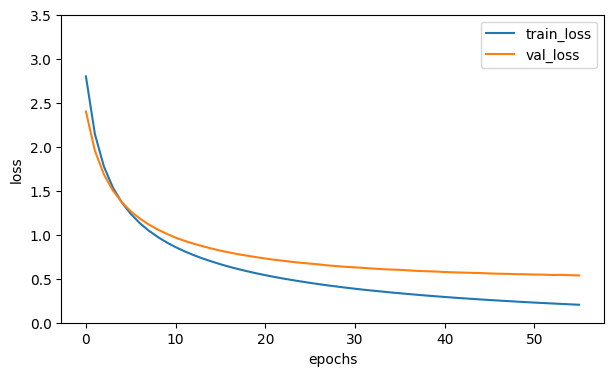

loss 0.19961825001220518


epoch:  59%|█████▉    | 57/96 [1:28:39<57:45, 88.86s/it]


Epoch 057 train_loss: 0.1996     val_loss 0.5360 train_acc 0.9701 val_acc 0.8606
loss 0.19533114590244263


epoch:  60%|██████    | 58/96 [1:30:08<56:19, 88.93s/it]


Epoch 058 train_loss: 0.1953     val_loss 0.5356 train_acc 0.9707 val_acc 0.8608
loss 0.1908840776375692


...


Epoch 062 train_loss: 0.1789     val_loss 0.5313 train_acc 0.9754 val_acc 0.8637
loss 0.1750285781517938


epoch:  66%|██████▌   | 63/96 [1:37:42<50:11, 91.24s/it]


Epoch 063 train_loss: 0.1750     val_loss 0.5273 train_acc 0.9762 val_acc 0.8645
loss 0.17125012281060412


epoch:  67%|██████▋   | 64/96 [1:39:18<49:30, 92.82s/it]


Epoch 064 train_loss: 0.1713     val_loss 0.5290 train_acc 0.9769 val_acc 0.8618


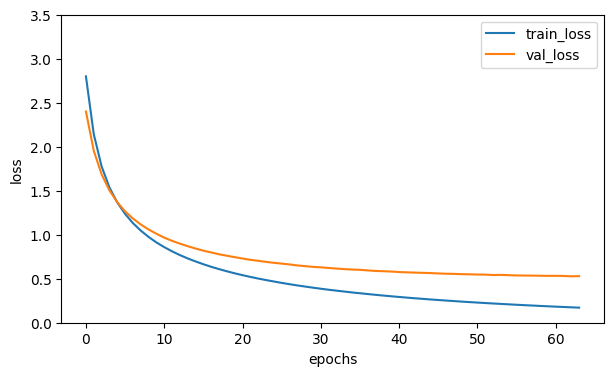

loss 0.1676529231720479


epoch:  68%|██████▊   | 65/96 [1:40:55<48:31, 93.91s/it]


Epoch 065 train_loss: 0.1677     val_loss 0.5269 train_acc 0.9785 val_acc 0.8612
loss 0.16410916006237702


epoch:  69%|██████▉   | 66/96 [1:42:26<46:33, 93.12s/it]


Epoch 066 train_loss: 0.1641     val_loss 0.5265 train_acc 0.9795 val_acc 0.8626
loss 0.16066767055499148


...


Epoch 070 train_loss: 0.1511     val_loss 0.5232 train_acc 0.9824 val_acc 0.8647
loss 0.14763803576229076


epoch:  74%|███████▍  | 71/96 [1:50:36<42:16, 101.47s/it]


Epoch 071 train_loss: 0.1476     val_loss 0.5224 train_acc 0.9836 val_acc 0.8637
loss 0.1450781916965383


epoch:  75%|███████▌  | 72/96 [1:53:12<47:05, 117.73s/it]


Epoch 072 train_loss: 0.1451     val_loss 0.5223 train_acc 0.9838 val_acc 0.8655


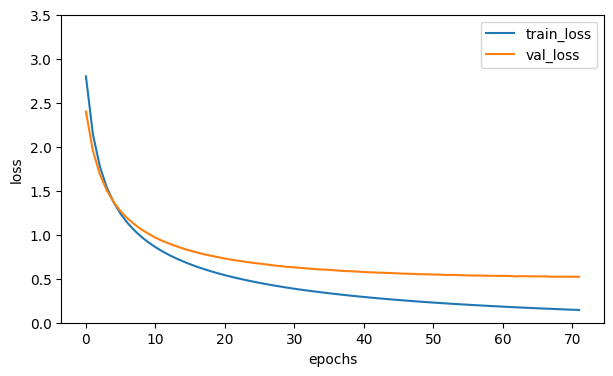

loss 0.14191229722659693


epoch:  76%|███████▌  | 73/96 [1:54:42<42:02, 109.67s/it]


Epoch 073 train_loss: 0.1419     val_loss 0.5231 train_acc 0.9844 val_acc 0.8655
loss 0.13908687918367216


epoch:  77%|███████▋  | 74/96 [1:56:12<37:59, 103.63s/it]


Epoch 074 train_loss: 0.1391     val_loss 0.5207 train_acc 0.9853 val_acc 0.8645
loss 0.1365518263353092


...


Epoch 075 train_loss: 0.1366     val_loss 0.5222 train_acc 0.9857 val_acc 0.8645
loss 0.13350085699789357


epoch:  79%|███████▉  | 76/96 [1:59:11<32:07, 96.38s/it]


Epoch 076 train_loss: 0.1335     val_loss 0.5195 train_acc 0.9860 val_acc 0.8643
loss 0.13095365260452368


epoch:  80%|████████  | 77/96 [2:00:43<30:08, 95.18s/it]


Epoch 077 train_loss: 0.1310     val_loss 0.5195 train_acc 0.9868 val_acc 0.8672


In [ ]:
history_mobileone_s4_without_outliers = train(train_dataset, val_dataset, model=mobileone_s4_without_outliers, epochs=64+32, batch_size=64, optimizer=optimizer, cb_checkpoint=plot_epoch_loss)

# Kaggle: Ефим_Плотников_1131261392



epoch:   0%|          | 0/512 [00:00<?, ?it/s]

loss 2.3778197481867185


epoch:   0%|          | 1/512 [03:18<28:13:34, 198.85s/it]


Epoch 001 train_loss: 2.3778     val_loss 1.0705 train_acc 0.5115 val_acc 0.8002
loss 0.41504786167564606


epoch:   0%|          | 2/512 [06:21<26:48:55, 189.29s/it]

...


Epoch 030 train_loss: 0.0000     val_loss 0.2155 train_acc 1.0000 val_acc 0.9719
loss 3.3745299499121623e-06


epoch:   6%|▌         | 31/512 [1:34:59<24:31:39, 183.57s/it]


Epoch 031 train_loss: 0.0000     val_loss 0.2174 train_acc 1.0000 val_acc 0.9717
loss 2.9573908441027973e-06


epoch:   6%|▋         | 32/512 [1:38:06<24:36:45, 184.59s/it]


Epoch 032 train_loss: 0.0000     val_loss 0.2193 train_acc 1.0000 val_acc 0.9717


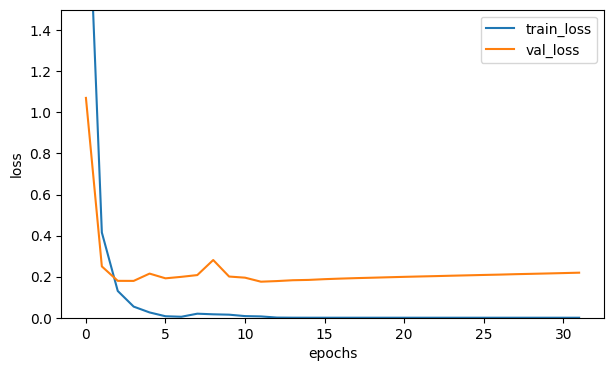

loss 2.596183138861797e-06


epoch:   6%|▋         | 33/512 [1:41:12<24:37:36, 185.09s/it]


Epoch 033 train_loss: 0.0000     val_loss 0.2212 train_acc 1.0000 val_acc 0.9715
loss 2.2765205341625485e-06


epoch:   7%|▋         | 34/512 [1:44:18<24:36:03, 185.28s/it]


Epoch 034 train_loss: 0.0000     val_loss 0.2231 train_acc 1.0000 val_acc 0.9717
loss 1.999082914906787e-06


...


Epoch 062 train_loss: 0.0000     val_loss 0.2783 train_acc 1.0000 val_acc 0.9713
loss 5.158927492957405e-08


epoch:  12%|█▏        | 63/512 [3:12:51<22:50:05, 183.08s/it]


Epoch 063 train_loss: 0.0000     val_loss 0.2802 train_acc 1.0000 val_acc 0.9713
loss 4.5049142903437084e-08


epoch:  12%|█▎        | 64/512 [3:15:53<22:44:04, 182.69s/it]


Epoch 064 train_loss: 0.0000     val_loss 0.2822 train_acc 1.0000 val_acc 0.9709


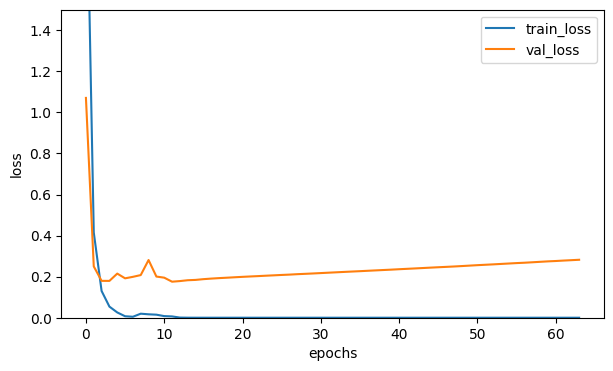

loss 3.941800314179261e-08


epoch:  13%|█▎        | 65/512 [3:18:51<22:31:15, 181.38s/it]


Epoch 065 train_loss: 0.0000     val_loss 0.2846 train_acc 1.0000 val_acc 0.9711
loss 3.431839303540486e-08


epoch:  13%|█▎        | 66/512 [3:21:56<22:37:02, 182.56s/it]


Epoch 066 train_loss: 0.0000     val_loss 0.2863 train_acc 1.0000 val_acc 0.9707
loss 2.999681944440365e-08


...


Epoch 094 train_loss: 0.0000     val_loss 0.3193 train_acc 1.0000 val_acc 0.9711
loss 6.316743838103228e-10


epoch:  19%|█▊        | 95/512 [4:50:27<21:12:38, 183.11s/it]


Epoch 095 train_loss: 0.0000     val_loss 0.3201 train_acc 1.0000 val_acc 0.9711
loss 5.623442721425142e-10


epoch:  19%|█▉        | 96/512 [4:53:32<21:12:34, 183.54s/it]


Epoch 096 train_loss: 0.0000     val_loss 0.3218 train_acc 1.0000 val_acc 0.9715


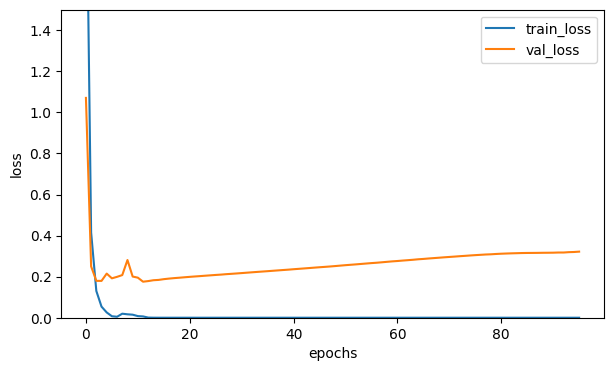

loss 5.007174997873997e-10


epoch:  19%|█▉        | 97/512 [4:56:38<21:14:56, 184.33s/it]


Epoch 097 train_loss: 0.0000     val_loss 0.3223 train_acc 1.0000 val_acc 0.9715
loss 4.776074625647969e-10


epoch:  19%|█▉        | 98/512 [4:59:33<20:53:32, 181.67s/it]


Epoch 098 train_loss: 0.0000     val_loss 0.3262 train_acc 1.0000 val_acc 0.9715
loss 5.161241940240665e-10


...


Epoch 126 train_loss: 0.0000     val_loss 0.2136 train_acc 1.0000 val_acc 0.9742
loss 3.13506510805873e-06


epoch:  25%|██▍       | 127/512 [6:28:18<19:39:01, 183.74s/it]


Epoch 127 train_loss: 0.0000     val_loss 0.2151 train_acc 1.0000 val_acc 0.9742
loss 2.7521334864795143e-06


epoch:  25%|██▌       | 128/512 [6:31:22<19:36:52, 183.89s/it]


Epoch 128 train_loss: 0.0000     val_loss 0.2165 train_acc 1.0000 val_acc 0.9742


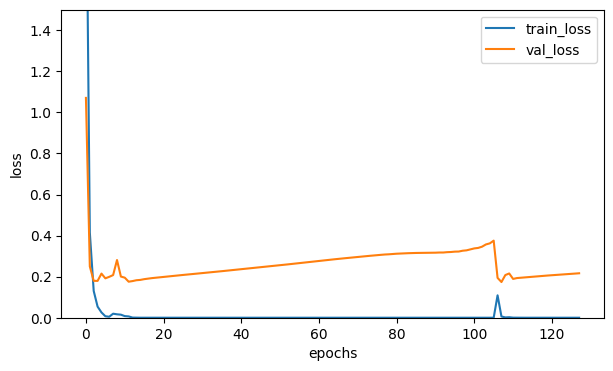

loss 2.4228339796342655e-06


epoch:  25%|██▌       | 129/512 [6:34:24<19:30:26, 183.36s/it]


Epoch 129 train_loss: 0.0000     val_loss 0.2179 train_acc 1.0000 val_acc 0.9746
loss 2.1300948124808614e-06


epoch:  25%|██▌       | 130/512 [6:37:27<19:26:48, 183.27s/it]


Epoch 130 train_loss: 0.0000     val_loss 0.2193 train_acc 1.0000 val_acc 0.9744
loss 1.8740313628302723e-06


...


Epoch 145 train_loss: 0.0000     val_loss 0.2414 train_acc 1.0000 val_acc 0.9746
loss 2.816409367147532e-07


epoch:  29%|██▊       | 146/512 [7:26:53<19:09:58, 188.52s/it]


Epoch 146 train_loss: 0.0000     val_loss 0.2430 train_acc 1.0000 val_acc 0.9746


epoch:  29%|██▊       | 146/512 [7:27:33<18:41:57, 183.93s/it]


KeyboardInterrupt: 

In [ ]:
mobileone_s4_3 = timm.create_model("mobileone_s4.apple_in1k", pretrained=True)
mobileone_s4_3 = mobileone_s4_3.to(DEVICE)

num_features = mobileone_s4_3.head.fc.in_features
mobileone_s4_3.head.fc = torch.nn.Linear(num_features, n_classes).to(DEVICE)

optimizer = torch.optim.Adam(mobileone_s4_3.parameters(), lr=2e-5)

history_mobileone_s4_3 = train(train_dataset, val_dataset, model=mobileone_s4_3, epochs=128*4, batch_size=64, optimizer=optimizer, cb_checkpoint=plot_epoch_loss)

In [104]:
checkpoint = torch.load("checkpoint_95.pth", map_location=DEVICE)

mobileone_s4_3.load_state_dict(checkpoint["model_state"])
optimizer.load_state_dict(checkpoint["optim_state"])

print(f"Starting from checkpoint {checkpoint['epoch']}")

history_mobileone_s4_3_2 = train(train_dataset, val_dataset, model=mobileone_s4_3, epochs=16, batch_size=64, optimizer=optimizer, cb_checkpoint=plot_epoch_loss)

C:\Users\efimplotnikov\AppData\Local\Temp\ipykernel_35000\1099006300.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("checkpoint_95.pth", map_loc

Starting from checkpoint 95


epoch:   0%|          | 0/16 [00:00<?, ?it/s]

loss 5.161241926466008e-10


epoch:   6%|▋         | 1/16 [02:49<42:23, 169.58s/it]

...


Epoch 014 train_loss: 0.0113     val_loss 0.1973 train_acc 0.9968 val_acc 0.9639
loss 0.0019149652054484794


epoch:  94%|█████████▍| 15/16 [38:11<02:26, 146.03s/it]


Epoch 015 train_loss: 0.0019     val_loss 0.1845 train_acc 0.9994 val_acc 0.9729
loss 0.0001815095568620803


epoch: 100%|██████████| 16/16 [40:36<00:00, 152.27s/it]


Epoch 016 train_loss: 0.0002     val_loss 0.1875 train_acc 1.0000 val_acc 0.9738


In [106]:
checkpoint = torch.load("best_model.pth", map_location=DEVICE)

mobileone_s4_3.load_state_dict(checkpoint["model_state"])

test_dataset = SimpsonsDataset(test_files, mode="test")
test_loader = DataLoader(test_dataset, shuffle=False, batch_size=64, num_workers=NUM_WORKERS)
predict_and_submit(mobileone_s4_3, "mobileone_s4_best_tuned")

C:\Users\efimplotnikov\AppData\Local\Temp\ipykernel_35000\3037872452.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("best_model.pth", map_locati

In [108]:
mobileone_s4_4 = timm.create_model("mobileone_s4.apple_in1k", pretrained=True)
mobileone_s4_4 = mobileone_s4_4.to(DEVICE)

num_features = mobileone_s4_4.head.fc.in_features
mobileone_s4_4.head.fc = torch.nn.Linear(num_features, n_classes).to(DEVICE)

optimizer = torch.optim.AdamW(mobileone_s4_4.parameters(), lr=2e-5, weight_decay=1e-2)

epoch:   0%|          | 0/96 [00:00<?, ?it/s]

loss 2.3587775578213814


epoch:   1%|          | 1/96 [03:55<6:12:55, 235.53s/it]


Epoch 001 train_loss: 2.3588     val_loss 1.0606 train_acc 0.5172 val_acc 0.8079
loss 0.41142219711004824


epoch:   2%|▏         | 2/96 [07:56<6:13:37, 238.48s/it]

...


Epoch 030 train_loss: 0.0000     val_loss 0.1665 train_acc 1.0000 val_acc 0.9773
loss 2.5589089500808093e-05


epoch:  32%|███▏      | 31/96 [2:01:34<4:05:17, 226.43s/it]


Epoch 031 train_loss: 0.0000     val_loss 0.1679 train_acc 1.0000 val_acc 0.9779
loss 1.9841308008697654e-05


epoch:  33%|███▎      | 32/96 [2:05:13<3:59:06, 224.17s/it]


Epoch 032 train_loss: 0.0000     val_loss 0.1691 train_acc 1.0000 val_acc 0.9777


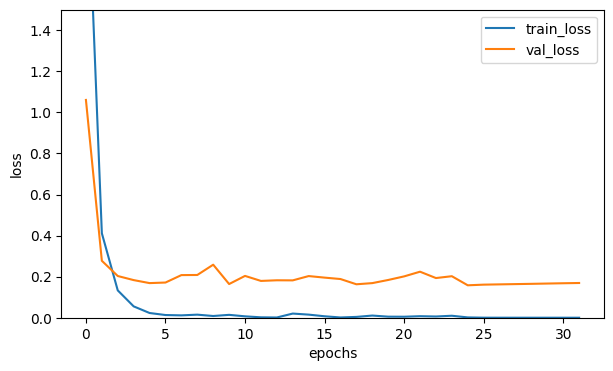

loss 1.5575303419757953e-05


epoch:  34%|███▍      | 33/96 [2:08:54<3:54:13, 223.08s/it]


Epoch 033 train_loss: 0.0000     val_loss 0.1705 train_acc 1.0000 val_acc 0.9779
loss 1.2360175567602845e-05


epoch:  35%|███▌      | 34/96 [2:12:26<3:47:05, 219.77s/it]


Epoch 034 train_loss: 0.0000     val_loss 0.1717 train_acc 1.0000 val_acc 0.9779
loss 9.923034277960871e-06


...


Epoch 062 train_loss: 0.0000     val_loss 0.2042 train_acc 1.0000 val_acc 0.9791
loss 1.8563241840802706e-07


epoch:  66%|██████▌   | 63/96 [3:57:50<1:58:54, 216.19s/it]


Epoch 063 train_loss: 0.0000     val_loss 0.2055 train_acc 1.0000 val_acc 0.9791
loss 1.630931800474005e-07


epoch:  67%|██████▋   | 64/96 [4:01:30<1:55:59, 217.49s/it]


Epoch 064 train_loss: 0.0000     val_loss 0.2067 train_acc 1.0000 val_acc 0.9791


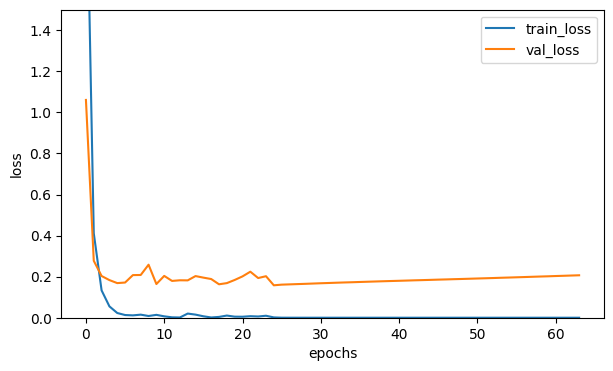

loss 1.429726180408572e-07


epoch:  68%|██████▊   | 65/96 [4:05:07<1:52:15, 217.27s/it]


Epoch 065 train_loss: 0.0000     val_loss 0.2080 train_acc 1.0000 val_acc 0.9791
loss 1.2578682361415652e-07


epoch:  69%|██████▉   | 66/96 [4:08:44<1:48:32, 217.10s/it]


Epoch 066 train_loss: 0.0000     val_loss 0.2093 train_acc 1.0000 val_acc 0.9791
loss 1.1083490318122804e-07


...


Epoch 094 train_loss: 0.0000     val_loss 0.2403 train_acc 1.0000 val_acc 0.9787
loss 2.603730822303373e-09


epoch:  99%|█████████▉| 95/96 [5:53:57<03:37, 217.53s/it]


Epoch 095 train_loss: 0.0000     val_loss 0.2408 train_acc 1.0000 val_acc 0.9787
loss 2.3187070634096036e-09


epoch: 100%|██████████| 96/96 [5:57:38<00:00, 218.62s/it]


Epoch 096 train_loss: 0.0000     val_loss 0.2414 train_acc 1.0000 val_acc 0.9787


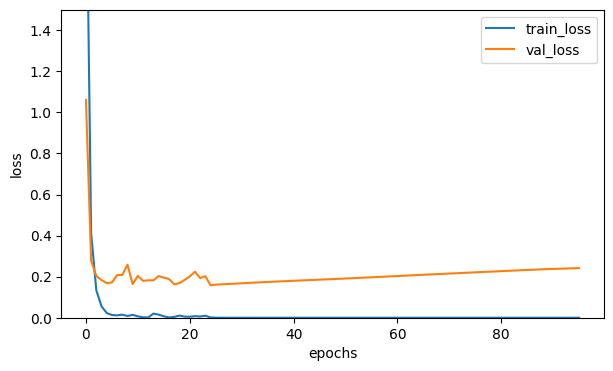

epoch: 100%|██████████| 96/96 [5:57:39<00:00, 223.53s/it]


In [109]:
history_mobileone_s4_4 = train(train_dataset, val_dataset, model=mobileone_s4_4, epochs=64+32, batch_size=64, optimizer=optimizer, cb_checkpoint=plot_epoch_loss)

epoch:   0%|          | 0/128 [00:00<?, ?it/s]

loss 2.6191376988246707e-10


epoch:   1%|          | 1/128 [03:06<6:34:33, 186.40s/it]


Epoch 001 train_loss: 0.0000     val_loss 0.2503 train_acc 1.0000 val_acc 0.9785
loss 1.6947361502303738e-10


epoch:   2%|▏         | 2/128 [06:12<6:30:27, 185.93s/it]

...


Epoch 030 train_loss: 0.0000     val_loss 0.3189 train_acc 1.0000 val_acc 0.9752
loss 1.8488030880054884e-10


epoch:  24%|██▍       | 31/128 [1:35:27<5:07:22, 190.13s/it]


Epoch 031 train_loss: 0.0000     val_loss 0.3244 train_acc 1.0000 val_acc 0.9748
loss 2.465070774824213e-10


epoch:  25%|██▌       | 32/128 [1:38:46<5:08:47, 193.00s/it]


Epoch 032 train_loss: 0.0000     val_loss 0.3271 train_acc 1.0000 val_acc 0.9744


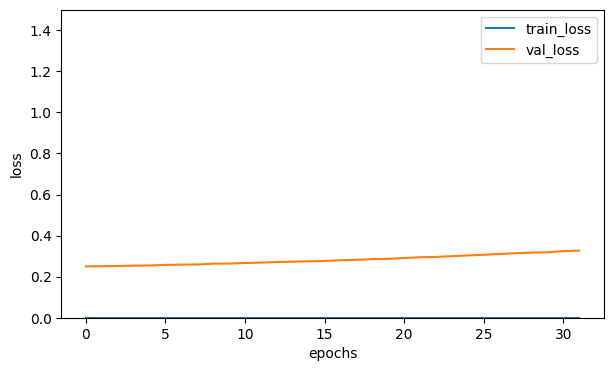

loss 2.233970398006632e-10


epoch:  26%|██▌       | 33/128 [1:41:50<5:01:21, 190.33s/it]


Epoch 033 train_loss: 0.0000     val_loss 0.3290 train_acc 1.0000 val_acc 0.9744
loss 2.465070765641108e-10


epoch:  27%|██▋       | 34/128 [1:44:54<4:55:08, 188.39s/it]


Epoch 034 train_loss: 0.0000     val_loss 0.3330 train_acc 1.0000 val_acc 0.9738
loss 1.8488030558646216e-10


...


Epoch 062 train_loss: 0.0000     val_loss 0.3148 train_acc 1.0000 val_acc 0.9748
loss 6.480449811075932e-07


epoch:  49%|████▉     | 63/128 [3:20:28<3:36:06, 199.48s/it]


Epoch 063 train_loss: 0.0000     val_loss 0.3143 train_acc 1.0000 val_acc 0.9748
loss 5.753729075492757e-07


epoch:  50%|█████     | 64/128 [3:23:49<3:33:25, 200.08s/it]


Epoch 064 train_loss: 0.0000     val_loss 0.3139 train_acc 1.0000 val_acc 0.9746


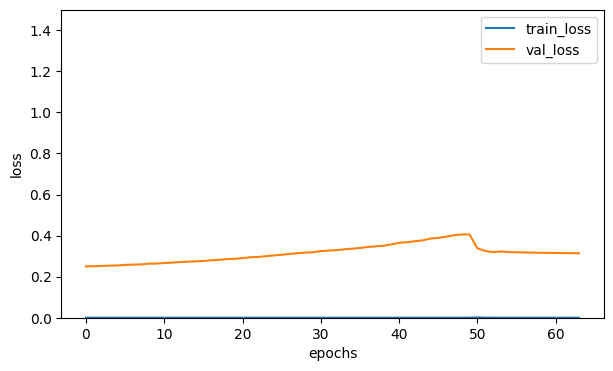

loss 5.149368294297126e-07


epoch:  51%|█████     | 65/128 [3:27:12<3:30:53, 200.84s/it]


Epoch 065 train_loss: 0.0000     val_loss 0.3135 train_acc 1.0000 val_acc 0.9746
loss 4.6378805810584333e-07


epoch:  52%|█████▏    | 66/128 [3:30:30<3:26:51, 200.18s/it]


Epoch 066 train_loss: 0.0000     val_loss 0.3131 train_acc 1.0000 val_acc 0.9744
loss 4.1748974766245144e-07


...


Epoch 094 train_loss: 0.0000     val_loss 0.3084 train_acc 1.0000 val_acc 0.9760
loss 3.4264424555560034e-08


epoch:  74%|███████▍  | 95/128 [5:07:01<1:49:45, 199.57s/it]


Epoch 095 train_loss: 0.0000     val_loss 0.3084 train_acc 1.0000 val_acc 0.9760
loss 3.146812009564599e-08


epoch:  75%|███████▌  | 96/128 [5:10:20<1:46:21, 199.41s/it]


Epoch 096 train_loss: 0.0000     val_loss 0.3084 train_acc 1.0000 val_acc 0.9760


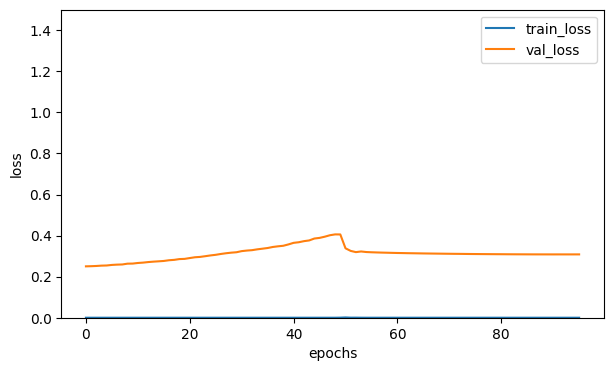

loss 2.8956838090165672e-08


epoch:  76%|███████▌  | 97/128 [5:13:40<1:43:00, 199.36s/it]


Epoch 097 train_loss: 0.0000     val_loss 0.3085 train_acc 1.0000 val_acc 0.9760
loss 2.644555484485141e-08


epoch:  77%|███████▋  | 98/128 [5:16:59<1:39:37, 199.24s/it]


Epoch 098 train_loss: 0.0000     val_loss 0.3086 train_acc 1.0000 val_acc 0.9760
loss 2.4157666935010957e-08


...


Epoch 126 train_loss: 0.0000     val_loss 0.3171 train_acc 1.0000 val_acc 0.9773
loss 1.479042446069163e-09


epoch:  99%|█████████▉| 127/128 [6:53:38<03:18, 199.00s/it]


Epoch 127 train_loss: 0.0000     val_loss 0.3175 train_acc 1.0000 val_acc 0.9773
loss 1.3480855652603266e-09


epoch: 100%|██████████| 128/128 [6:56:57<00:00, 199.05s/it]


Epoch 128 train_loss: 0.0000     val_loss 0.3183 train_acc 1.0000 val_acc 0.9769


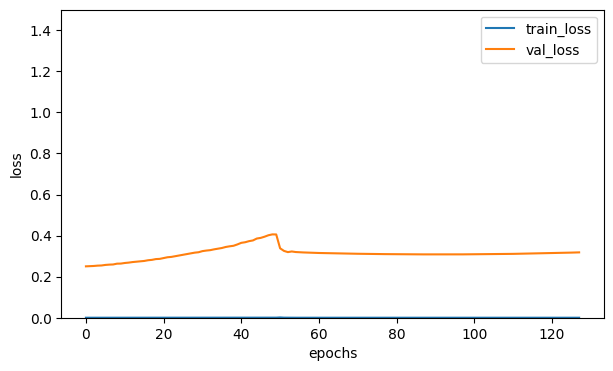

epoch: 100%|██████████| 128/128 [6:56:57<00:00, 195.45s/it]


[(2.6191376988246707e-10,
  np.float64(1.0),
  0.2502625872348676,
  tensor(0.9785, device='cuda:0', dtype=torch.float64)),
 (1.6947361502303738e-10,
  np.float64(1.0),
  0.25095833380562144,
  tensor(0.9785, device='cuda:0', dtype=torch.float64)),
 (3.0813384800091476e-10,
  np.float64(1.0),
  0.2520080461196137,
  tensor(0.9785, device='cuda:0', dtype=torch.float64)),
 (1.8488030880054884e-10,
  np.float64(1.0),
  0.25366286560550627,
  tensor(0.9783, device='cuda:0', dtype=torch.float64)),
 (2.3110038554153081e-10,
  np.float64(1.0),
  0.254409513502838,
  tensor(0.9783, device='cuda:0', dtype=torch.float64)),
 (2.002870012005946e-10,
  np.float64(1.0),
  0.2571008620069638,
  tensor(0.9779, device='cuda:0', dtype=torch.float64)),
 (2.1569369176401935e-10,
  np.float64(1.0),
  0.2585642508695905,
  tensor(0.9775, device='cuda:0', dtype=torch.float64)),
 (2.002870002822841e-10,
  np.float64(1.0),
  0.2593407595933344,
  tensor(0.9775, device='cuda:0', dtype=torch.float64)),
 (2.31100

In [111]:
optimizer = torch.optim.AdamW(mobileone_s4_4.parameters(), lr=2e-6, weight_decay=1e-2)
train(train_dataset, val_dataset, model=mobileone_s4_4, epochs=128, batch_size=64, optimizer=optimizer, cb_checkpoint=plot_epoch_loss)

In [112]:
checkpoint = torch.load("best_model.pth", map_location=DEVICE)

mobileone_s4_4.load_state_dict(checkpoint["model_state"])

test_dataset = SimpsonsDataset(test_files, mode="test")
test_loader = DataLoader(test_dataset, shuffle=False, batch_size=64, num_workers=NUM_WORKERS)
predict_and_submit(mobileone_s4_4, "mobileone_s4_4")

C:\Users\efimplotnikov\AppData\Local\Temp\ipykernel_35000\867130641.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("best_model.pth", map_locatio